# AIDS × High-Dimensional IV: Monte Carlo Simulation

Computational companion to the paper. Modules `aids_core.py`, `aids_experiments.py`, and `aids_plots.py` must be in the same folder. Monte Carlo results are cached under `mc_cache/`; a cell that has already been executed reloads its results.

Estimator slate is defined in `FULL_CFG` below. Main-paper tier: OLS, 2SLS, 2SLS-LassoFS, Post-Lasso-IV, Debiased-HDIV, Debiased-HDIV-CF. Appendix tier: 2SLS-EnetFS, Debiased-HDIV-Ridge, Debiased-HDIV-Nodewise.

## 1. Setup

### 1.1 Imports and plotting defaults


In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aids_core import (
    draw_aids_params, simulate_aids_iv, build_yX_from_summary,
    get_true_params, condition_number, min_eig_XtX,
    EstimatorConfig, fit_debiased_hd_iv,
)
from aids_experiments import mc_sweep_n, mc_sweep_pz

import aids_plots
from aids_plots import plot_mc_bands, plot_rmse, plot_coverage, plot_instability

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


### 1.2 Scenarios and estimator configuration

`SCENARIOS` keys: `A_no_endo` (ρ_u = 0), `B_strongIV` (ρ_u = 0.6, k = 1.0), `C_weakIV` (ρ_u = 0.6, k = 0.2). `FULL_CFG` carries the nine-estimator slate used by `mc_sweep_n` / `mc_sweep_pz`.

In [ ]:
SCENARIOS = {
    "A_no_endo":  dict(rho_u=0.0, rho_x=0.0, instr_strength=1.0,
                       correlated_prices=True, rho_col=0.95,
                       k_instr_per_price=5, recompute_stone=False),
    "B_strongIV": dict(rho_u=0.6, rho_x=0.0, instr_strength=1.0,
                       correlated_prices=True, rho_col=0.95,
                       k_instr_per_price=5, recompute_stone=False),
    "C_weakIV":   dict(rho_u=0.6, rho_x=0.0, instr_strength=0.2,
                       correlated_prices=True, rho_col=0.95,
                       k_instr_per_price=5, recompute_stone=False),
}

# Estimator slate. The ridge and nodewise precision variants are gated to
# n_goods >= 200 to save MC time; below this they coincide with mainline
# CLIME. The actual boundary regime where they differ substantively from
# mainline is n_goods = 300, where p_x = 302 > T = 300 and mainline CLIME
# is costly to solve.
FULL_CFG = EstimatorConfig(
    include_ols=True,
    include_2sls_plain=True,
    include_2sls_lassoFS=True,       # main: Lasso first stage
    include_post_lasso_iv=True,      # main: Post-Lasso IV 
    include_2sls_enetFS=True,        # appendix: elastic-net first stage 
    include_two_stage_lasso=False,
    include_debiased=True,           # main: debiased HD-IV 
    include_debiased_cf=True,        # main: debiased HD-IV with cross-fitted first stage
    include_debiased_ridge=True,     # appendix: ridge-regularized precision plug-in
    include_debiased_nodewise=True,  # appendix: nodewise-Lasso precision plug-in
    robust_variants_min_n_goods=200,
    cv=5,
    lasso_n_jobs=1,
)

# Design constants.
T_DEFAULT = 300
PZ_DEFAULT = 350     # satisfies the order condition p_z >= p_x at every grid point
N_GOODS_DEFAULT = 100
PARAM_SEED = 20
SEED = 20

# Monte Carlo grids.
N_GRID_PUB  = [50, 100, 150, 200, 250, 300]   # p_x = n_goods + 2 spans well below T to just above it
PZ_GRID_PUB = [110, 200, 300, 400, 500]       # instrument count swept above and below T


## 2. The dimensionality problem (paper §3.3, Appendix A)

In [3]:
import os
os.makedirs("figs", exist_ok=True)

# Toy LA-AIDS data-generating process for the dimensionality illustration.

def simulate_aids_toy(T=300, n_goods=8, rho=0.95, noise=0.01,
                       correlated_prices=True, seed=20):
    """
    Simulate one AIDS share equation and estimate by OLS.
    Returns diagnostics: condition number, min eigenvalue, RMSE, R2.
    Parameters are drawn fresh each call from the same seed so that
    the true target is comparable across n_goods values.
    """
    rng = np.random.default_rng(seed)

    # Log prices
    if correlated_prices:
        common = rng.normal(0, 1, size=T).cumsum()
        log_p = np.column_stack([
            common + rng.normal(0, (1 - rho), size=T)
            for _ in range(n_goods)
        ])
    else:
        log_p = np.zeros((T, n_goods))
        for j in range(n_goods):
            eps = rng.normal(0, 1, size=T)
            for t in range(1, T):
                log_p[t, j] = rho * log_p[t-1, j] + eps[t]

    # Log total expenditure
    common_x = rng.normal(0, 1, size=T).cumsum()
    log_x = 0.5 * common_x + rng.normal(0, 0.3, size=T) + 5

    # True parameters, satisfying adding-up, homogeneity, and symmetry
    alpha = rng.uniform(0.02, 0.2, size=n_goods)
    alpha /= alpha.sum()
    beta = rng.normal(0, 0.1, size=n_goods)
    beta -= beta.mean()
    g = rng.normal(0, 0.03, size=(n_goods, n_goods))
    gamma = (g + g.T) / 2
    gamma -= gamma.mean(axis=1, keepdims=True)

    # Stone price index, alpha as initial weights
    log_Pstar = log_p @ alpha

    # Budget shares
    log_x_over_P = log_x - log_Pstar
    w = np.zeros((T, n_goods))
    for i in range(n_goods):
        w[:, i] = (alpha[i]
                   + log_p @ gamma[i]
                   + beta[i] * log_x_over_P
                   + rng.normal(0, noise, T))

    # Recompute Stone index with realised shares
    log_Pstar = (log_p * w).sum(axis=1)
    log_x_over_P = log_x - log_Pstar

    # Design matrix and OLS for good 1
    X = np.column_stack([np.ones(T), log_x_over_P, log_p])
    y = w[:, 0]

    true_params = np.concatenate(([alpha[0], beta[0]], gamma[0, :]))

    try:
        est_params = np.linalg.lstsq(X, y, rcond=None)[0]
        r2 = float(1 - np.var(y - X @ est_params) / np.var(y))
        rmse = float(np.sqrt(np.mean((est_params - true_params) ** 2)))
        max_err = float(np.max(np.abs(est_params - true_params)))
    except np.linalg.LinAlgError:
        est_params = np.full(X.shape[1], np.nan)
        r2 = rmse = max_err = np.nan

    return {
        'n_goods': n_goods,
        'T': T,
        'k': X.shape[1],
        'cond_number': condition_number(X),
        'min_eigen': min_eig_XtX(X),
        'R2': r2,
        'rmse': rmse,
        'max_err': max_err,
        'true_params': true_params,
        'est_params': est_params,
        'X': X,
        'y': y,
    }


def simulate_aids_orthogonal(T=300, n_goods=8, noise=0.01, seed=20):
    rng = np.random.default_rng(seed)
    k = n_goods + 2  # total regressors

    if k <= T:
        # orthogonal columns via QR of a square Gaussian matrix
        raw = rng.normal(size=(T, T))
        Q, _ = np.linalg.qr(raw)
        X = Q[:, :k] * np.sqrt(T)   # (T, k), columns orthogonal
    else:
        # k > T: orthogonality is impossible, so use a random Gaussian design
        X = rng.normal(size=(T, k))

    # True parameters
    alpha = rng.uniform(0.02, 0.2, size=n_goods)
    alpha /= alpha.sum()
    beta = rng.normal(0, 0.1, size=n_goods)
    beta -= beta.mean()
    g = rng.normal(0, 0.03, size=(n_goods, n_goods))
    gamma = (g + g.T) / 2
    gamma -= gamma.mean(axis=1, keepdims=True)
    true_params = np.concatenate(([alpha[0], beta[0]], gamma[0, :]))

    y = X @ true_params + rng.normal(0, noise, T)

    try:
        est_params = np.linalg.lstsq(X, y, rcond=None)[0]
        r2 = float(1 - np.var(y - X @ est_params) / np.var(y))
        rmse = float(np.sqrt(np.mean((est_params - true_params) ** 2)))
        max_err = float(np.max(np.abs(est_params - true_params)))
    except np.linalg.LinAlgError:
        est_params = np.full(k, np.nan)
        r2 = rmse = max_err = np.nan

    return {
        'n_goods': n_goods, 'T': T, 'k': k,
        'cond_number': condition_number(X),
        'min_eigen': min_eig_XtX(X),
        'R2': r2, 'rmse': rmse, 'max_err': max_err,
        'true_params': true_params, 'est_params': est_params,
        'X': X, 'y': y,
    }

def run_toy_sweep(goods_list, T=300, seed=20, correlated=True,
                   orthogonal=False):
    results = []
    for n in goods_list:
        if orthogonal:
            r = simulate_aids_orthogonal(T=T, n_goods=n, seed=seed)
        else:
            r = simulate_aids_toy(T=T, n_goods=n, seed=seed,
                                   correlated_prices=correlated)
        results.append(r)
    return pd.DataFrame([{k: v for k, v in r.items()
                           if k not in ('true_params','est_params','X','y')}
                          for r in results]), results


def plot_toy_diagnostics(df, savepath=None, T=300):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()
    n_vals = df['n_goods'].values

    titles = [
        "Condition Number of $X$ (log scale)",
        "Smallest Eigenvalue of $X'X$ (log scale)",
        "$R^2$",
        "OLS RMSE vs True Parameters",
    ]
    cols  = ['cond_number', 'min_eigen', 'R2', 'rmse']
    ylogs = [True, True, False, False]

    for ax, col, ttl, use_log in zip(axes, cols, titles, ylogs):
        y_vals = df[col].replace([np.inf, -np.inf], np.nan).copy()
        
        # log scale cannot show non-positive values
        if use_log:
            y_vals = y_vals.where(y_vals > 0, np.nan)
        
        finite = y_vals.notna().values
        
        if finite.any():
            ax.plot(n_vals[finite], y_vals.values[finite],
                    marker='o', linewidth=1.5)
        
        if use_log:
            ax.set_yscale('log')
            # widen the range for near-constant data so the line stays visible
            if finite.any():
                y_finite = y_vals.values[finite]
                ymin, ymax = float(np.min(y_finite)), float(np.max(y_finite))
                if ymin > 0 and ymax / ymin < 2:
                    ax.set_ylim(ymin / 10, ymax * 10)
        
        # reference lines, drawn after set_ylim to avoid retriggering autoscale
        ax.axvline(T, color='red', linestyle='--', alpha=0.8,
                   label=f'$n = T = {T}$')
        # shade the rank-deficient region where OLS is undefined
        if (~finite).any():
            ax.axvspan(T - 1, n_vals.max() + 5,
                       alpha=0.08, color='red', label='OLS undefined')
        
        ax.set_title(ttl, fontsize=11)
        ax.set_xlabel("Number of goods $n$")
        ax.set_xticks(n_vals[::2])
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, which='both', linestyle='--', alpha=0.4)
        if col == 'cond_number':
            ax.legend(fontsize=9)

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches='tight', dpi=150)
        print(f"Saved: {savepath}")
    plt.show()

### 2.1 Correlated prices (paper Figure 1)

Saved: figs/aids_simulation_corr.png


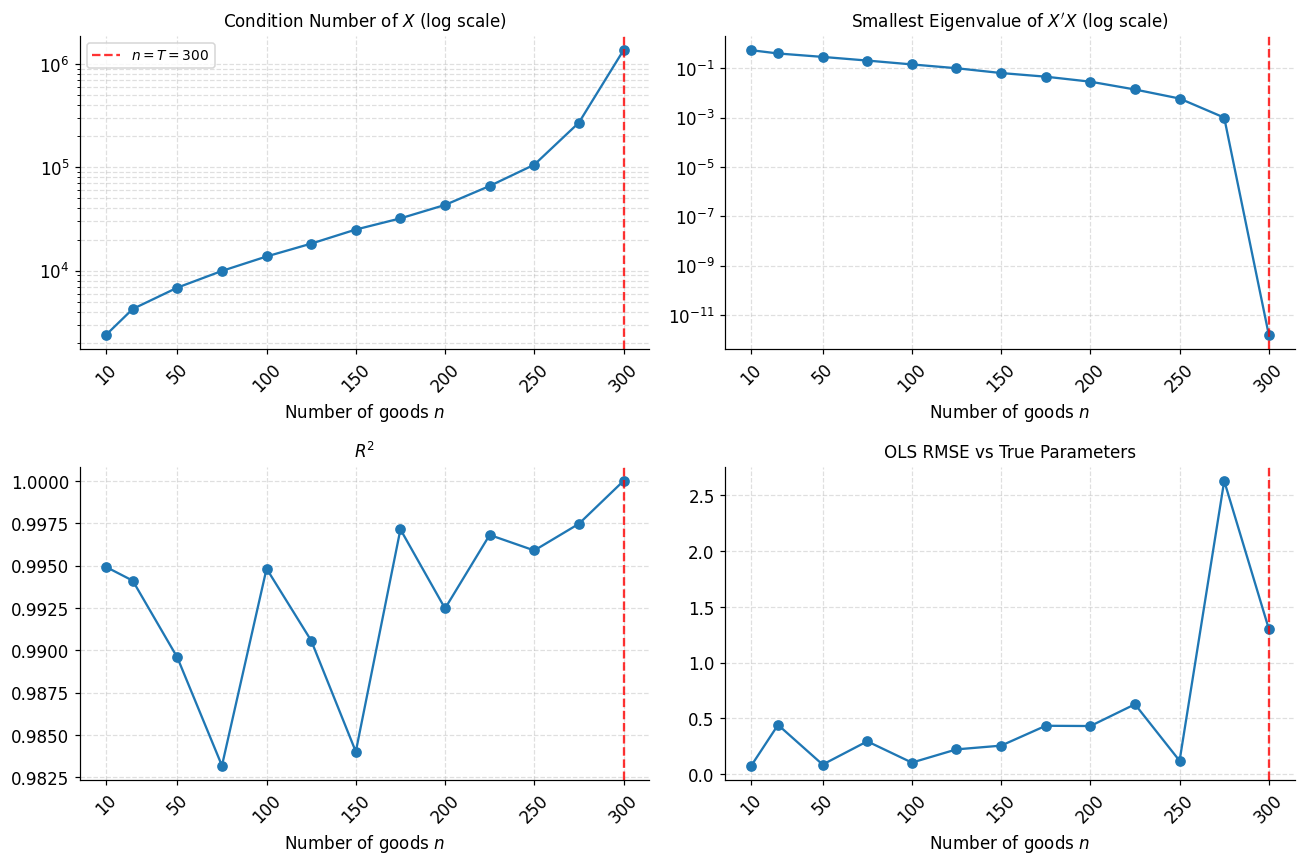

 n_goods   k  cond_number    min_eigen       R2     rmse
      10  12 2.383276e+03 5.470662e-01 0.994923 0.075616
      25  27 4.253511e+03 4.032174e-01 0.994109 0.441428
      50  52 6.846208e+03 2.926863e-01 0.989571 0.085556
      75  77 9.939310e+03 2.080064e-01 0.983180 0.294001
     100 102 1.371657e+04 1.451305e-01 0.994819 0.103254
     125 127 1.826879e+04 1.017224e-01 0.990569 0.221914
     150 152 2.500634e+04 6.492402e-02 0.984009 0.255337
     175 177 3.208402e+04 4.618410e-02 0.997139 0.433511
     200 202 4.328385e+04 2.895863e-02 0.992468 0.431096
     225 227 6.606877e+04 1.396421e-02 0.996810 0.626187
     250 252 1.061037e+05 6.010545e-03 0.995892 0.119438
     275 277 2.711204e+05 1.012313e-03 0.997468 2.628417
     300 302 1.363511e+06 1.558515e-12 1.000000 1.302094


In [4]:
T_TOY = 300
GOODS_LIST = [10, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]

df_corr, _ = run_toy_sweep(GOODS_LIST, T=T_TOY, seed=20, correlated=True)
plot_toy_diagnostics(
    df_corr,
    savepath="figs/aids_simulation_corr.png",
    T=T_TOY,
)
print(df_corr[['n_goods','k','cond_number','min_eigen','R2','rmse']].to_string(index=False))

### 2.2 Isolating the role of price collinearity (paper Appendix A)

Saved: figs/aids_simulation_no_corr.png


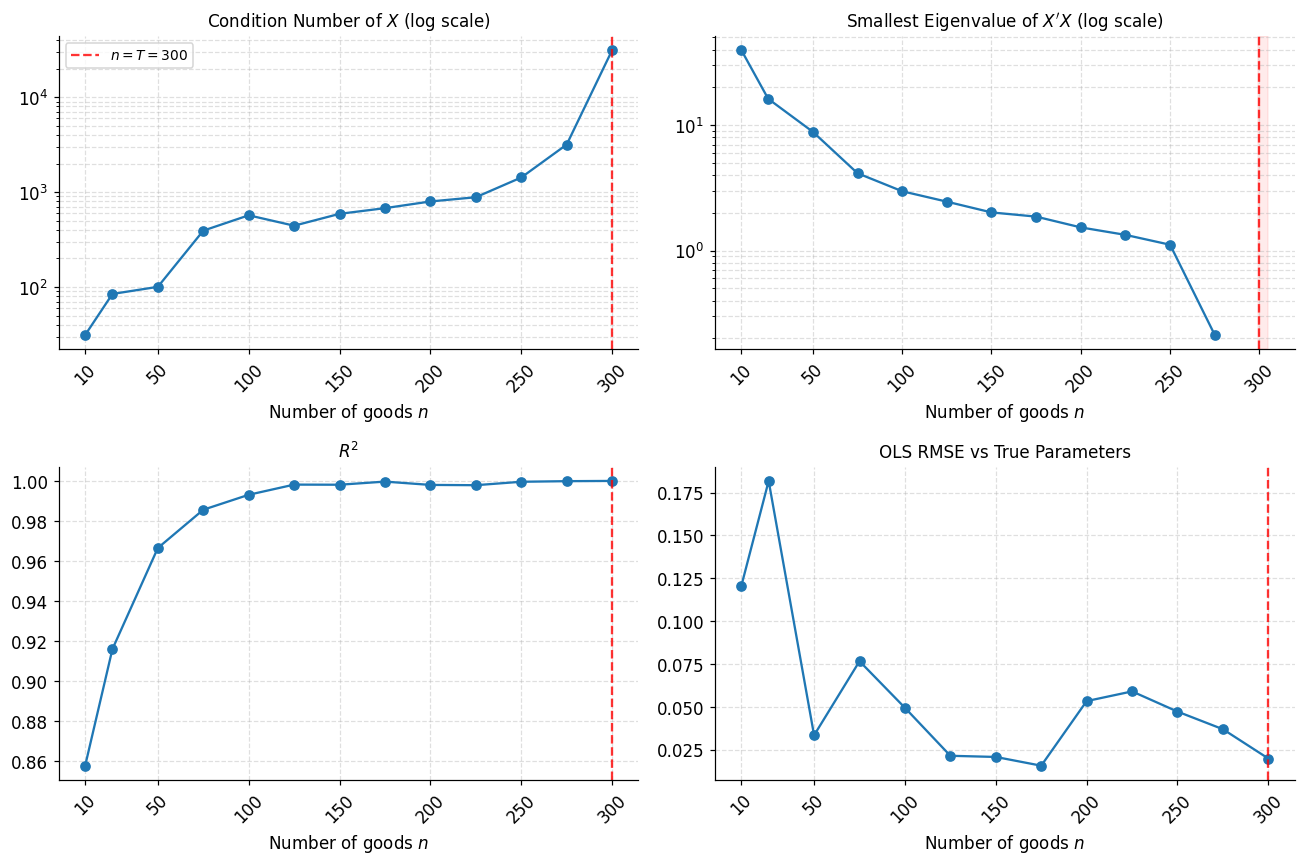

 n_goods   k  cond_number     min_eigen       R2     rmse
      10  12    31.178654  3.956529e+01 0.857737 0.120694
      25  27    84.366299  1.621349e+01 0.915971 0.181763
      50  52   100.262038  8.848347e+00 0.966500 0.033460
      75  77   392.010848  4.138118e+00 0.985604 0.076648
     100 102   569.143103  2.973974e+00 0.993079 0.049476
     125 127   442.086819  2.456566e+00 0.998163 0.021497
     150 152   589.552986  2.016361e+00 0.998104 0.020817
     175 177   676.828181  1.866766e+00 0.999662 0.015720
     200 202   796.096146  1.531310e+00 0.998008 0.053386
     225 227   882.174869  1.335428e+00 0.997867 0.059036
     250 252  1424.098746  1.114123e+00 0.999582 0.047261
     275 277  3166.373540  2.127715e-01 0.999881 0.036984
     300 302 31277.796512 -7.790786e-14 1.000000 0.019896


In [5]:
# Independent AR(1) prices
df_nocorr, _ = run_toy_sweep(GOODS_LIST, T=T_TOY, seed=20, correlated=False)
plot_toy_diagnostics(
    df_nocorr,
    savepath="figs/aids_simulation_no_corr.png",
    T=T_TOY,
)
print(df_nocorr[['n_goods','k','cond_number','min_eigen','R2','rmse']].to_string(index=False))

Saved: figs/aids_simulation_best.png


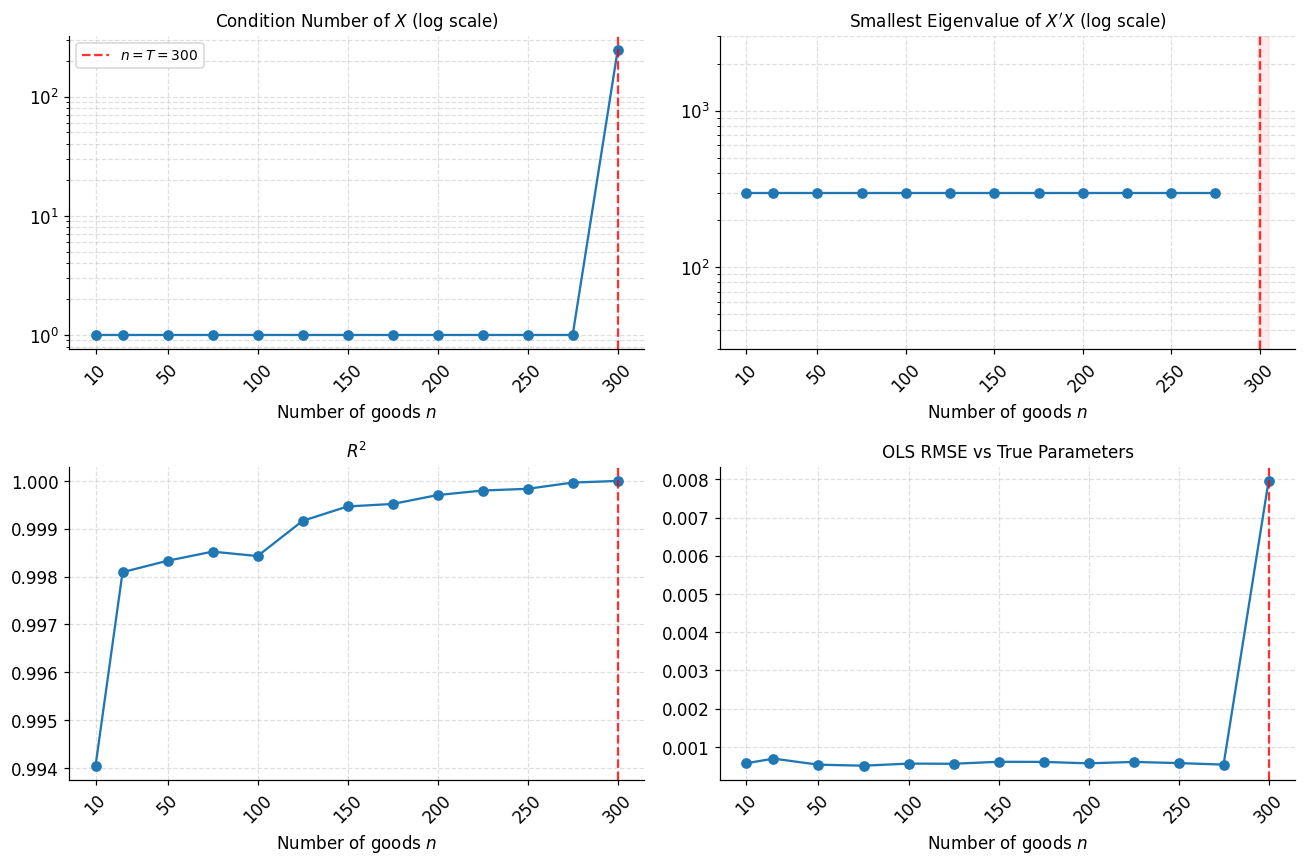

 n_goods   k  cond_number     min_eigen       R2     rmse
      10  12     1.000000  3.000000e+02 0.994047 0.000571
      25  27     1.000000  3.000000e+02 0.998092 0.000692
      50  52     1.000000  3.000000e+02 0.998332 0.000533
      75  77     1.000000  3.000000e+02 0.998522 0.000507
     100 102     1.000000  3.000000e+02 0.998429 0.000562
     125 127     1.000000  3.000000e+02 0.999165 0.000558
     150 152     1.000000  3.000000e+02 0.999467 0.000609
     175 177     1.000000  3.000000e+02 0.999519 0.000606
     200 202     1.000000  3.000000e+02 0.999705 0.000569
     225 227     1.000000  3.000000e+02 0.999799 0.000606
     250 252     1.000000  3.000000e+02 0.999835 0.000575
     275 277     1.000000  3.000000e+02 0.999966 0.000536
     300 302   245.164578 -5.650848e-14 1.000000 0.007957


In [6]:
# Orthogonal regressors: isolates dimensionality from collinearity
df_best, _ = run_toy_sweep(GOODS_LIST, T=T_TOY, seed=20, orthogonal=True)
plot_toy_diagnostics(
    df_best,
    savepath="figs/aids_simulation_best.png",
    T=T_TOY,
)
print(df_best[['n_goods','k','cond_number','min_eigen','R2','rmse']].to_string(index=False))

### 2.3 Further diagnostics (paper Appendix A)

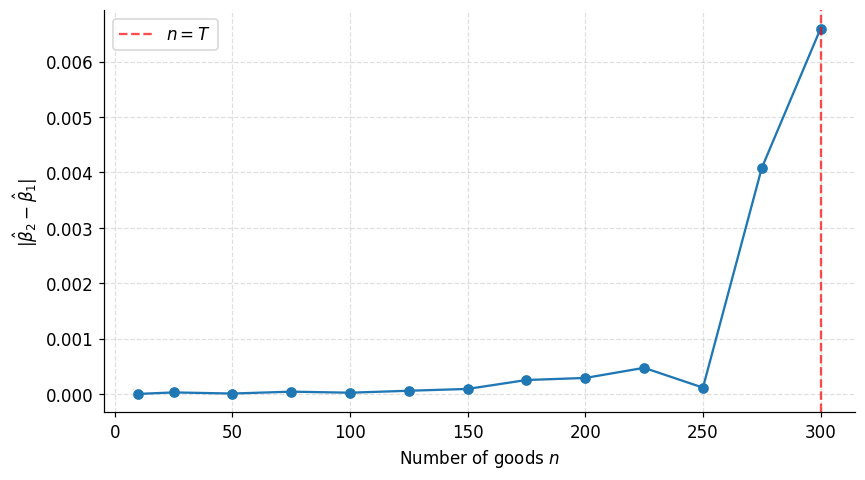

In [7]:
# Perturbation sensitivity of the OLS solution
def perturb_sensitivity(y, X, eps=1e-6, seed=20):
    rng2 = np.random.default_rng(seed)
    noise = rng2.normal(size=X.shape)
    X2 = X + eps * noise
    try:
        b1 = np.linalg.lstsq(X, y, rcond=None)[0]
        b2 = np.linalg.lstsq(X2, y, rcond=None)[0]
        return float(np.linalg.norm(b2 - b1))
    except Exception:
        return np.nan

_, results_corr  = run_toy_sweep(GOODS_LIST, T=T_TOY, seed=20, correlated=True)
_, results_best  = run_toy_sweep(GOODS_LIST, T=T_TOY, seed=20, orthogonal=True)

sens_corr = [perturb_sensitivity(r['y'], r['X']) for r in results_corr]
sens_best = [perturb_sensitivity(r['y'], r['X']) for r in results_best]

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(GOODS_LIST, sens_corr, marker='o', linewidth=1.5)
ax.axvline(T_TOY, color='red', linestyle='--', alpha=0.7, label='$n=T$')
ax.set_xlabel("Number of goods $n$")
ax.set_ylabel(r"$\|\hat{\beta}_2 - \hat{\beta}_1\|$")
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
fig.savefig("figs/aids_sensitivity_combined.png", bbox_inches='tight', dpi=150)
plt.show()
plt.show()

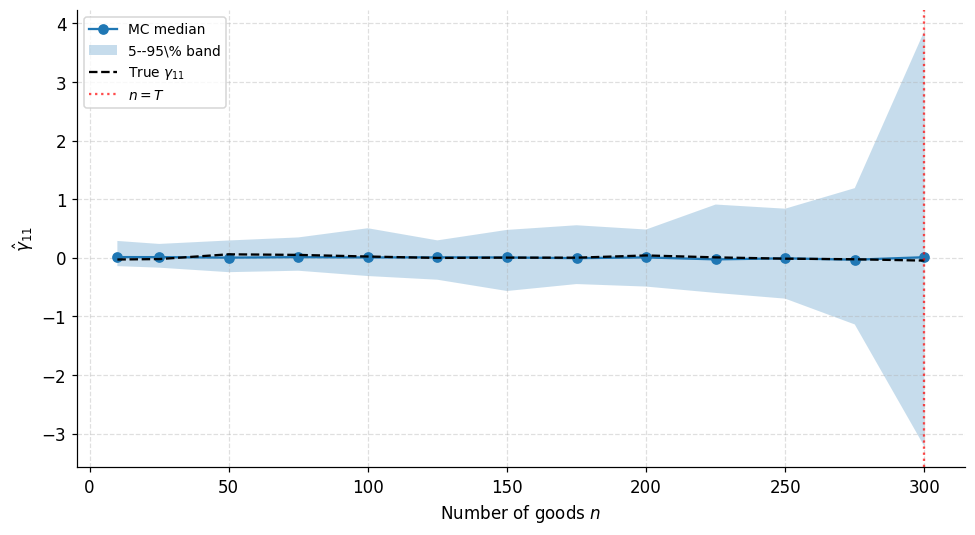

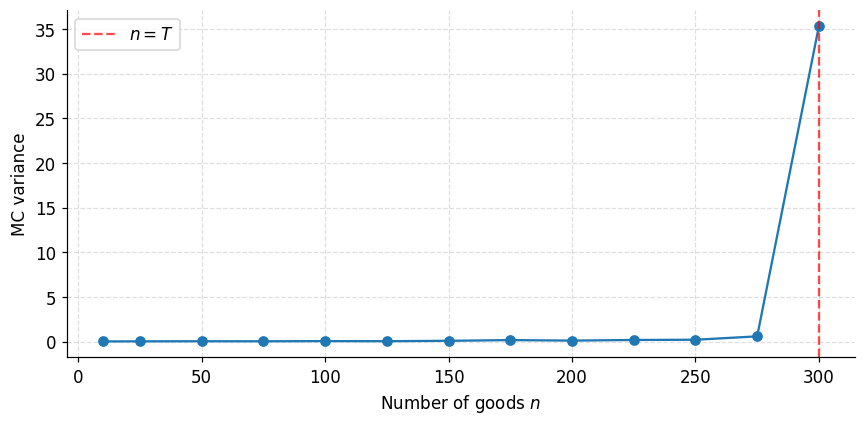

In [8]:
# Monte Carlo confidence bands for the own-price coefficient
N_REPS = 100

def mc_confidence_bands(goods_list, T=300, n_reps=100, seed=0,
                          correlated=True, orthogonal=False):
    records = []
    for n in goods_list:
        estimates = []
        for rep in range(n_reps):
            if orthogonal:
                r = simulate_aids_orthogonal(T=T, n_goods=n, seed=seed+rep)
            else:
                r = simulate_aids_toy(T=T, n_goods=n, seed=seed+rep,
                                       correlated_prices=correlated)
            # gamma[0,0], the own-price coefficient, is at parameter index 2
            est = r['est_params']
            true_val = r['true_params']
            if len(est) > 2:
                estimates.append(est[2])
        arr = np.array(estimates)
        records.append({
            'n_goods': n,
            'q05': np.nanpercentile(arr, 5),
            'q50': np.nanpercentile(arr, 50),
            'q95': np.nanpercentile(arr, 95),
            'var': np.nanvar(arr),
            'true': r['true_params'][2],
        })
    return pd.DataFrame(records)

df_mc_corr = mc_confidence_bands(GOODS_LIST, T=T_TOY, n_reps=N_REPS,
                                   correlated=True)
df_mc_best = mc_confidence_bands(GOODS_LIST, T=T_TOY, n_reps=N_REPS,
                                   orthogonal=True)

# confidence bands, correlated-price design
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.plot(df_mc_corr['n_goods'], df_mc_corr['q50'], marker='o',
        label='MC median', linewidth=1.5)
ax.fill_between(df_mc_corr['n_goods'], df_mc_corr['q05'], df_mc_corr['q95'],
                alpha=0.25, label='5--95\\% band')
ax.plot(df_mc_corr['n_goods'], df_mc_corr['true'], linestyle='--',
        color='black', label=r'True $\gamma_{11}$')
ax.axvline(T_TOY, color='red', linestyle=':', alpha=0.7, label='$n=T$')
ax.set_xlabel("Number of goods $n$")
ax.set_ylabel(r"$\hat{\gamma}_{11}$")
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig("figs/aids_monte_carlo_confidence_bands.png",
            bbox_inches='tight', dpi=150)
plt.show()

# Monte Carlo variance, correlated-price design
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(df_mc_corr['n_goods'], df_mc_corr['var'], marker='o', linewidth=1.5)
ax.axvline(T_TOY, color='red', linestyle='--', alpha=0.7, label='$n=T$')
ax.set_xlabel("Number of goods $n$")
ax.set_ylabel("MC variance")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig("figs/aids_parameter_variance.png", bbox_inches='tight', dpi=150)
plt.show()

## 3. Monte Carlo design (paper §§5.1–5.3)

In [9]:
N_REPS_PUB = 100

df_mc_n = {}
for scen_name, scen_kwargs in SCENARIOS.items():
    print(f"\n{'='*60}")
    print(f"MC sweep over n, scenario {scen_name}")
    print(f"{'='*60}")
    df_mc_n[scen_name] = mc_sweep_n(
        N_GRID_PUB, T=T_DEFAULT, pz=PZ_DEFAULT, i=0,
        n_reps=N_REPS_PUB, seed=0,
        scenario_kwargs=scen_kwargs, config=FULL_CFG,
        random_state=SEED, param_seed=PARAM_SEED,
        n_jobs=-1,
        cache_key=f"mc_n_{scen_name}_T{T_DEFAULT}_pz{PZ_DEFAULT}_reps{N_REPS_PUB}",
    )



MC sweep over n, scenario A_no_endo
[cache hit] loading combined cache for mc_n_A_no_endo_T300_pz350_reps100

MC sweep over n, scenario B_strongIV
[cache hit] loading combined cache for mc_n_B_strongIV_T300_pz350_reps100

MC sweep over n, scenario C_weakIV
[cache hit] loading combined cache for mc_n_C_weakIV_T300_pz350_reps100


In [10]:
df_mc_pz = {}
for scen_name in ["B_strongIV", "C_weakIV"]:
    print(f"\n{'='*60}")
    print(f"MC sweep over pz, scenario {scen_name}")
    print(f"{'='*60}")
    df_mc_pz[scen_name] = mc_sweep_pz(
        PZ_GRID_PUB, T=T_DEFAULT, n_goods=N_GOODS_DEFAULT, i=0,
        n_reps=N_REPS_PUB, seed=0,
        scenario_kwargs=SCENARIOS[scen_name], config=FULL_CFG,
        random_state=SEED, param_seed=PARAM_SEED,
        n_jobs=-1,
        cache_key=f"mc_pz_{scen_name}_T{T_DEFAULT}_n{N_GOODS_DEFAULT}_reps{N_REPS_PUB}",
    )



MC sweep over pz, scenario B_strongIV
[cache hit] loading combined cache for mc_pz_B_strongIV_T300_n100_reps100

MC sweep over pz, scenario C_weakIV
[cache hit] loading combined cache for mc_pz_C_weakIV_T300_n100_reps100


In [11]:
# Restrict to the six main-paper estimators; the three robustness variants are reported separately.
MAIN_ESTS = [
    "OLS", "2SLS",
    "2SLS-LassoFS", "Post-Lasso-IV",
    "Debiased-HDIV", "Debiased-HDIV-CF",
]
df_mc_n_main  = {k: v[v["estimator"].isin(MAIN_ESTS)].reset_index(drop=True)
                 for k, v in df_mc_n.items()}
df_mc_pz_main = {k: v[v["estimator"].isin(MAIN_ESTS)].reset_index(drop=True)
                 for k, v in df_mc_pz.items()}
print(f"Main estimator slate ({len(MAIN_ESTS)}): {MAIN_ESTS}")

Main estimator slate (6): ['OLS', '2SLS', '2SLS-LassoFS', 'Post-Lasso-IV', 'Debiased-HDIV', 'Debiased-HDIV-CF']


## 4. Asymptotic validation (paper §5.4, Figure 2)

In [12]:
T_GRID_ROBUST = [100, 200, 300, 500]
N_GOODS_FIXED = 100

df_mc_T = {}
for T_val in T_GRID_ROBUST:
    print(f"\n[T-sweep] T={T_val}")
    df_part = mc_sweep_n(
        [N_GOODS_FIXED], T=T_val, pz=PZ_DEFAULT, i=0,
        n_reps=N_REPS_PUB, seed=0,
        scenario_kwargs=SCENARIOS["B_strongIV"],
        config=FULL_CFG,
        random_state=SEED, param_seed=PARAM_SEED,
        n_jobs=-1,
        cache_key=f"mc_T_B_strongIV_n{N_GOODS_FIXED}_T{T_val}_pz{PZ_DEFAULT}_reps{N_REPS_PUB}",
    )
    df_part["T"] = T_val
    df_mc_T[T_val] = df_part

df_T_sweep = pd.concat(df_mc_T.values(), ignore_index=True)
print(f"\nT-sweep complete: {len(df_T_sweep)} rows ({len(df_T_sweep.estimator.unique())} estimators × {len(T_GRID_ROBUST)} T values)")



[T-sweep] T=100
[cache hit] loading combined cache for mc_T_B_strongIV_n100_T100_pz350_reps100

[T-sweep] T=200
[cache hit] loading combined cache for mc_T_B_strongIV_n100_T200_pz350_reps100

[T-sweep] T=300
[cache hit] loading combined cache for mc_T_B_strongIV_n100_T300_pz350_reps100

[T-sweep] T=500
[cache hit] loading combined cache for mc_T_B_strongIV_n100_T500_pz350_reps100

T-sweep complete: 28 rows (7 estimators × 4 T values)


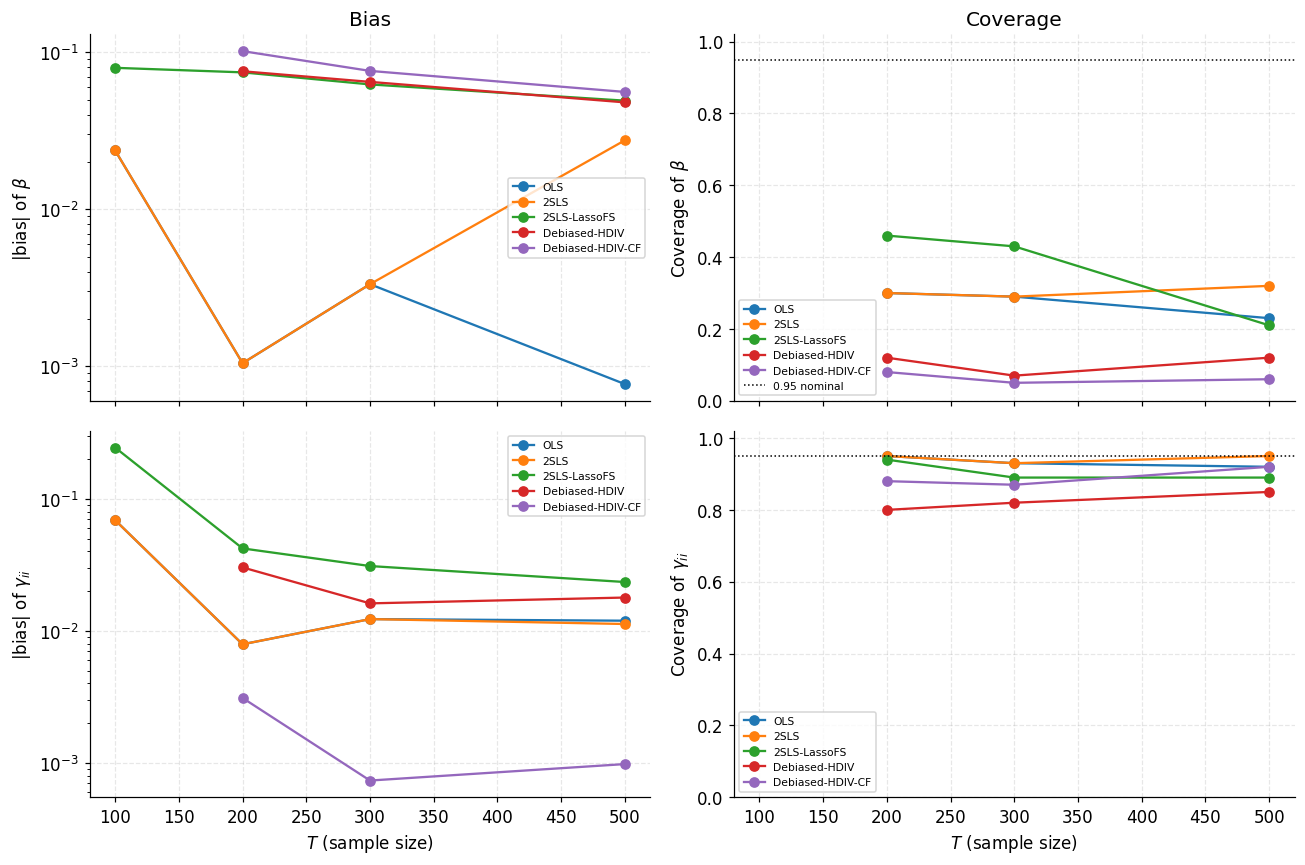

In [13]:
ESTS_T_SWEEP = ["OLS", "2SLS", "2SLS-LassoFS",
                "Debiased-HDIV", "Debiased-HDIV-CF"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for est in ESTS_T_SWEEP:
    g = df_T_sweep[df_T_sweep.estimator == est].sort_values("T").dropna(subset=["beta_bias"])
    if not g.empty:
        axes[0, 0].plot(g["T"], g["beta_bias"].abs(), marker="o", label=est)
    g_cov = df_T_sweep[df_T_sweep.estimator == est].sort_values("T").dropna(subset=["beta_coverage"])
    if not g_cov.empty:
        axes[0, 1].plot(g_cov["T"], g_cov["beta_coverage"], marker="o", label=est)

axes[0, 0].set_ylabel(r"$|\mathrm{bias}|$ of $\beta$")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Bias")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(fontsize=7, loc="best")

axes[0, 1].axhline(0.95, color="black", ls=":", lw=1, label="0.95 nominal")
axes[0, 1].set_ylabel(r"Coverage of $\beta$")
axes[0, 1].set_ylim(0, 1.02)
axes[0, 1].set_title("Coverage")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(fontsize=7, loc="best")

for est in ESTS_T_SWEEP:
    g = df_T_sweep[df_T_sweep.estimator == est].sort_values("T").dropna(subset=["gii_bias"])
    if not g.empty:
        axes[1, 0].plot(g["T"], g["gii_bias"].abs(), marker="o", label=est)
    g_cov = df_T_sweep[df_T_sweep.estimator == est].sort_values("T").dropna(subset=["gii_coverage"])
    if not g_cov.empty:
        axes[1, 1].plot(g_cov["T"], g_cov["gii_coverage"], marker="o", label=est)

axes[1, 0].set_xlabel(r"$T$ (sample size)")
axes[1, 0].set_ylabel(r"$|\mathrm{bias}|$ of $\gamma_{ii}$")
axes[1, 0].set_yscale("log")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(fontsize=7, loc="best")

axes[1, 1].axhline(0.95, color="black", ls=":", lw=1)
axes[1, 1].set_xlabel(r"$T$ (sample size)")
axes[1, 1].set_ylabel(r"Coverage of $\gamma_{ii}$")
axes[1, 1].set_ylim(0, 1.02)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(fontsize=7, loc="best")

plt.tight_layout()
if Path("paper_results").exists():
    plt.savefig("paper_results/fig5_3_T_sweep_B.pdf", bbox_inches="tight")
plt.show()

## 5. Results (paper §5.5)

### 5.1 Scenario A: calibration check (paper Appendix B.3)

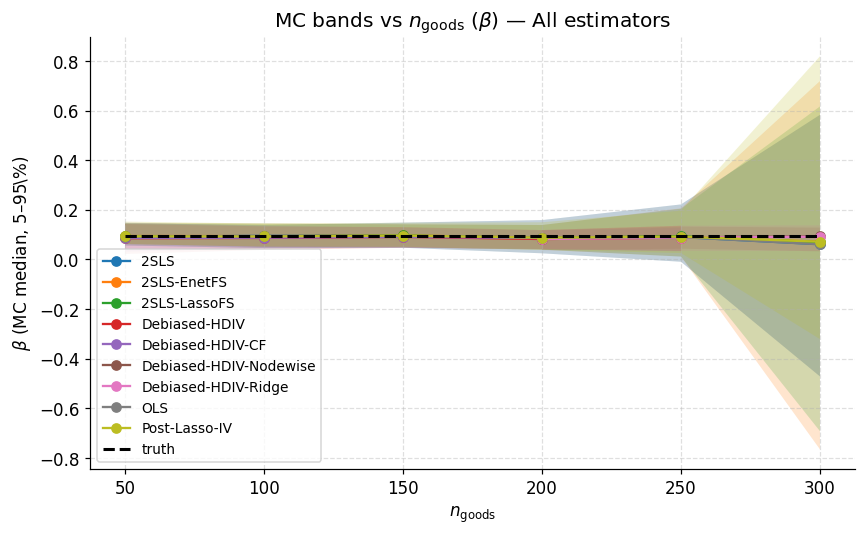

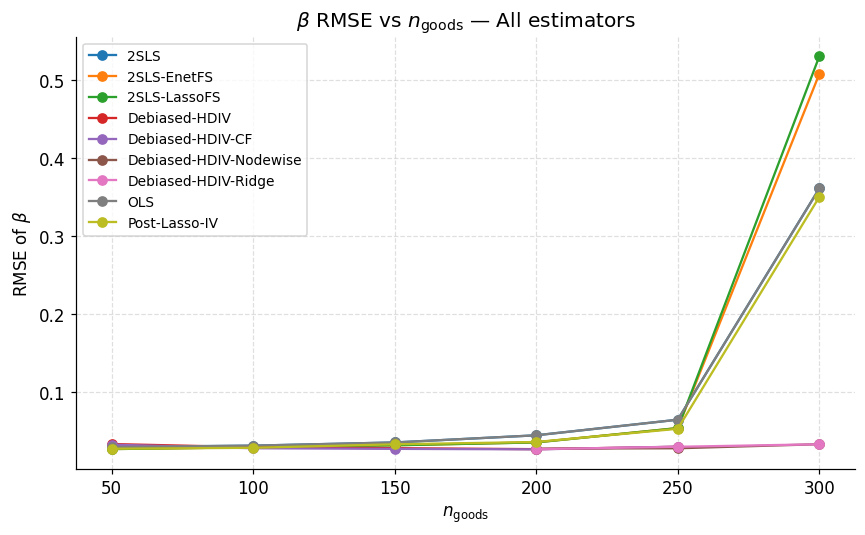

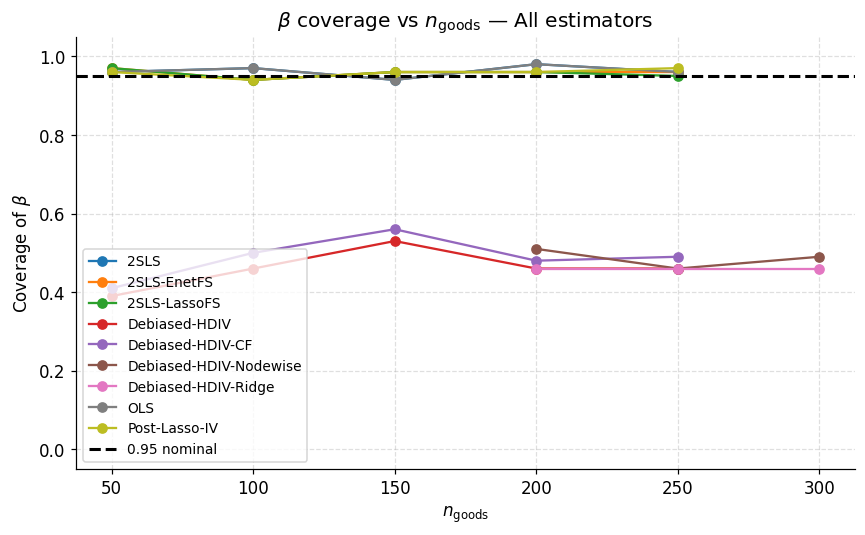

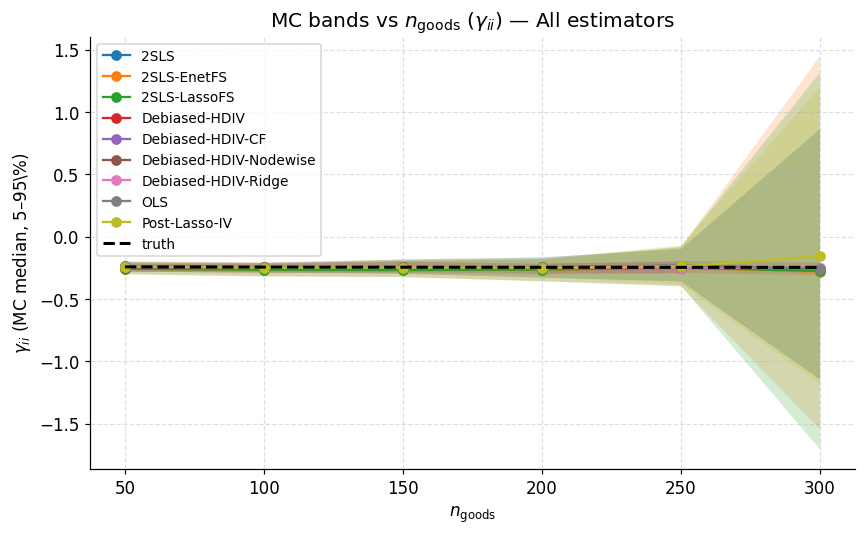

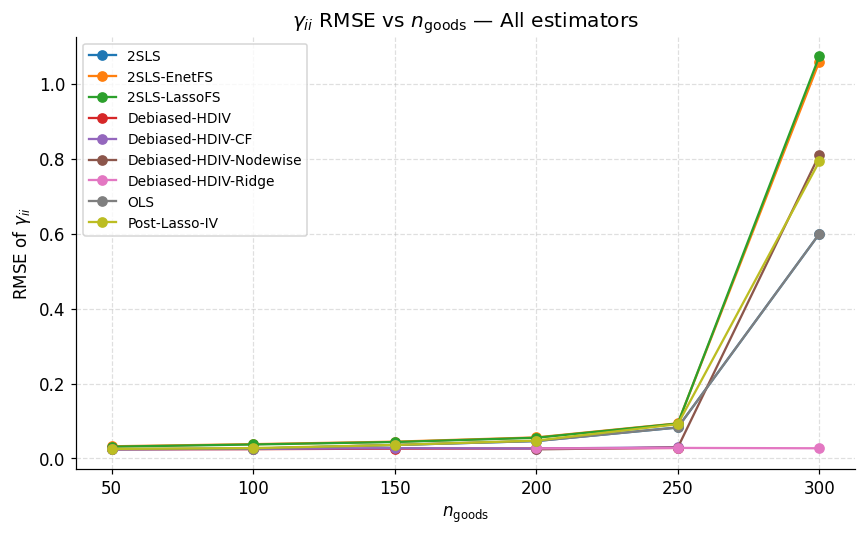

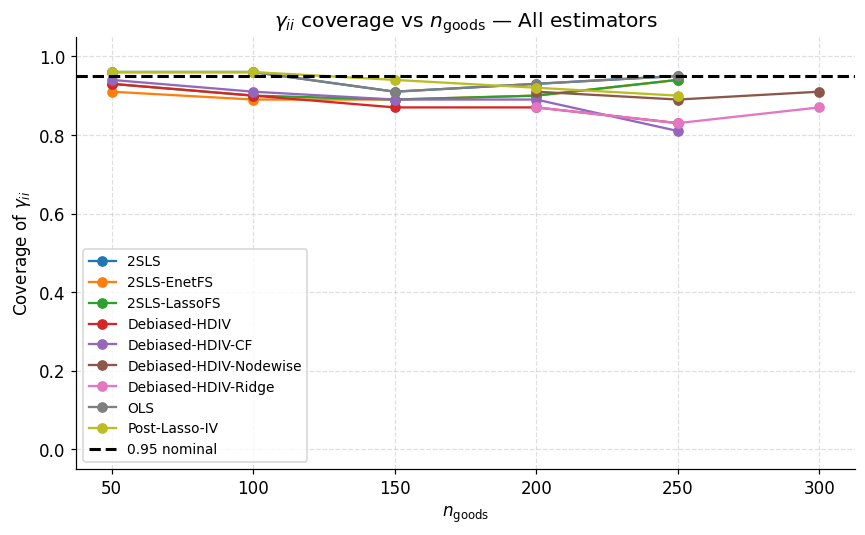

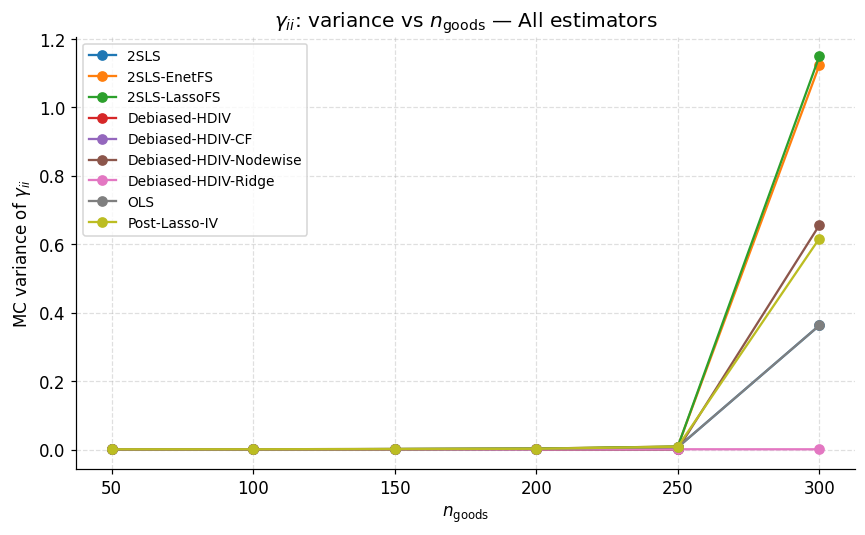

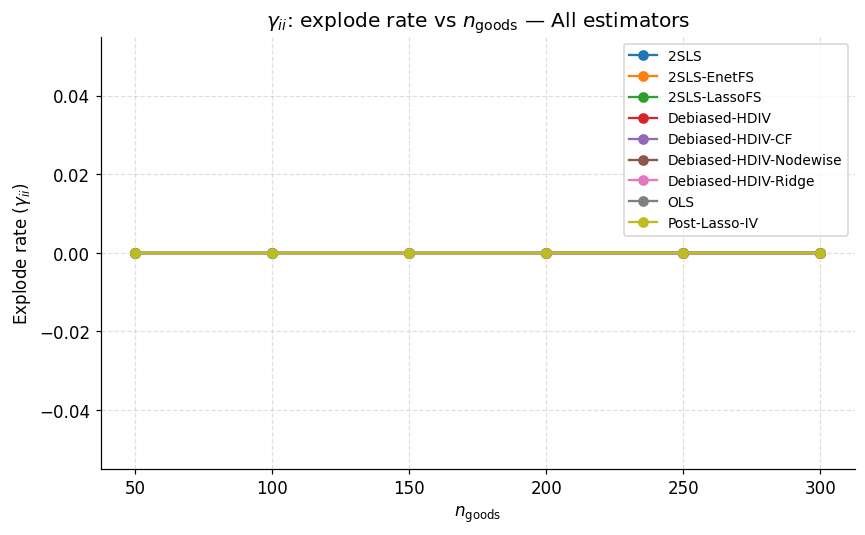

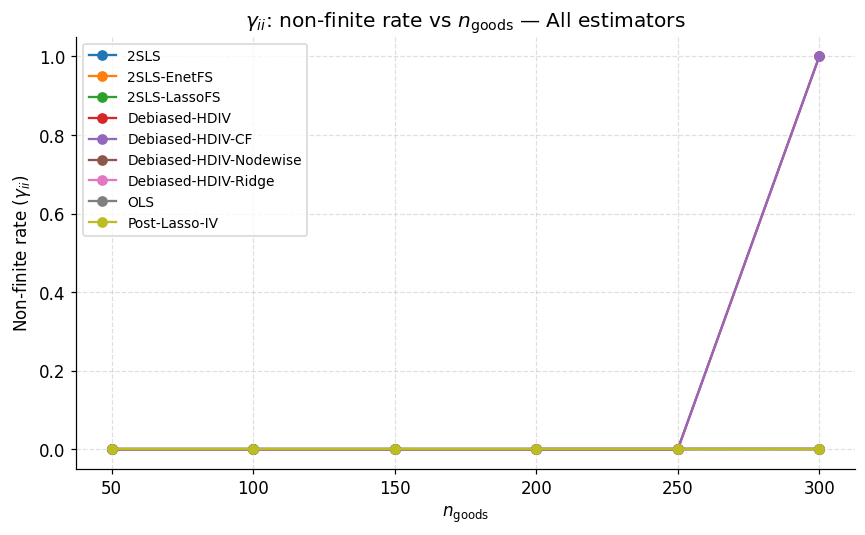

In [14]:
scen = "A_no_endo"
df = df_mc_n[scen]
aids_plots.set_filename_prefix("app_scenA_n")
for tgt in ("beta", "gii"):
    plot_mc_bands(df, xcol="n_goods", target=tgt, only_all=True)
    plot_rmse(df, xcol="n_goods", target=tgt, only_all=True)
    plot_coverage(df, xcol="n_goods", target=tgt, only_all=True)
plot_instability(df, xcol="n_goods", target="gii", only_all=True)

### 5.2 Scenario B: primary results (paper §5.5.1)

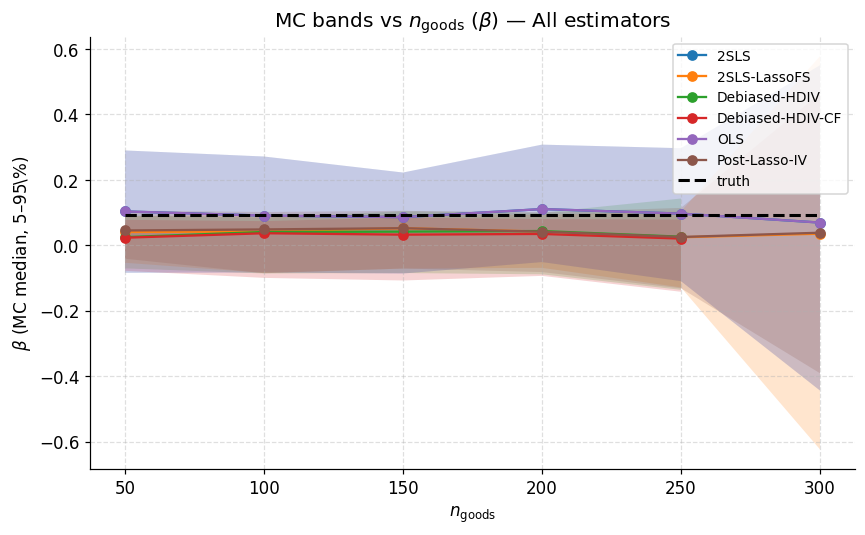

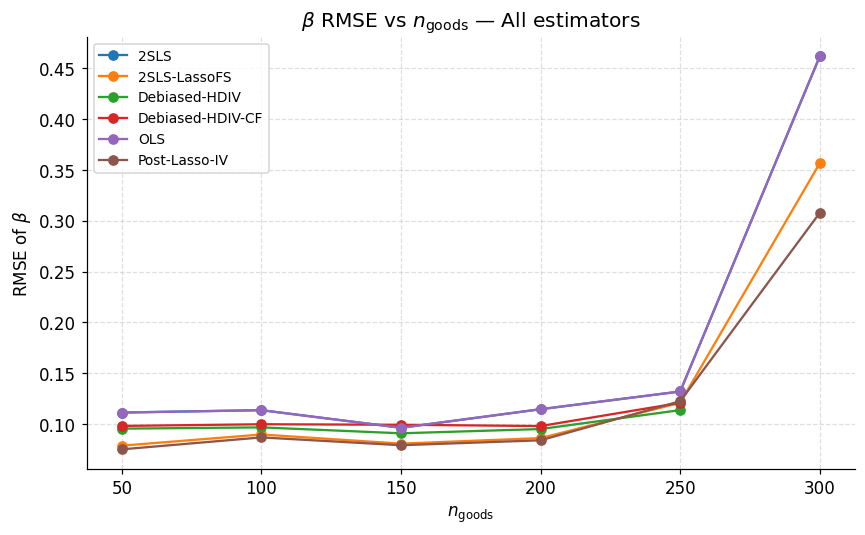

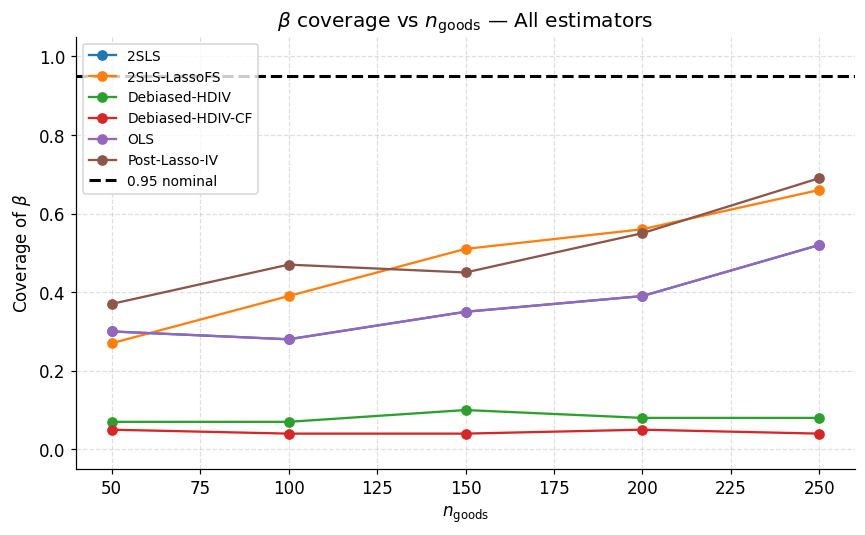

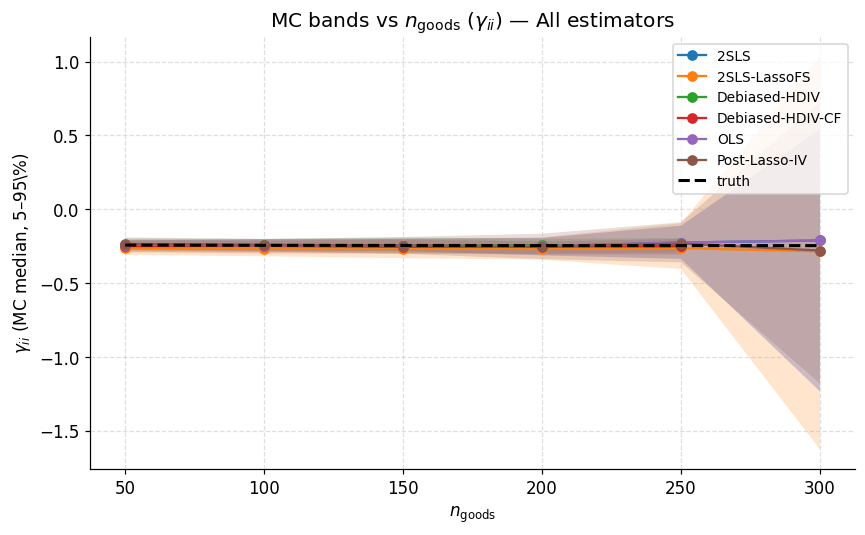

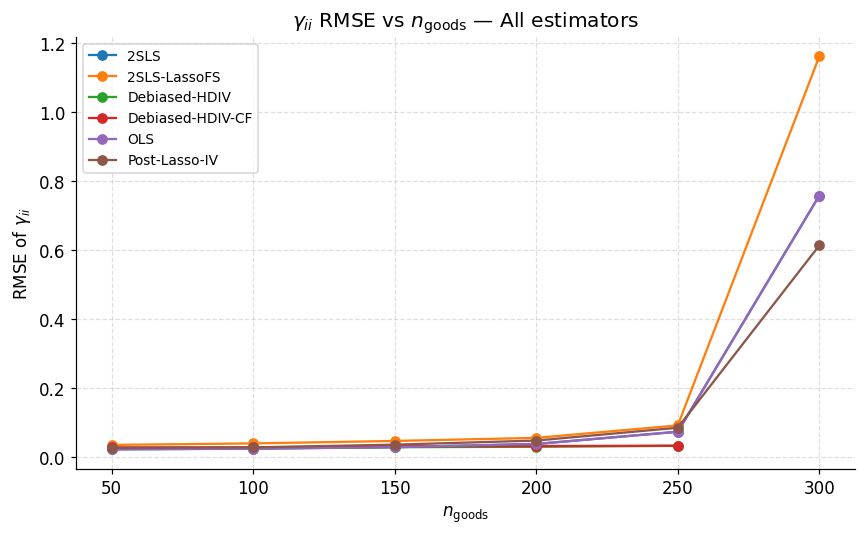

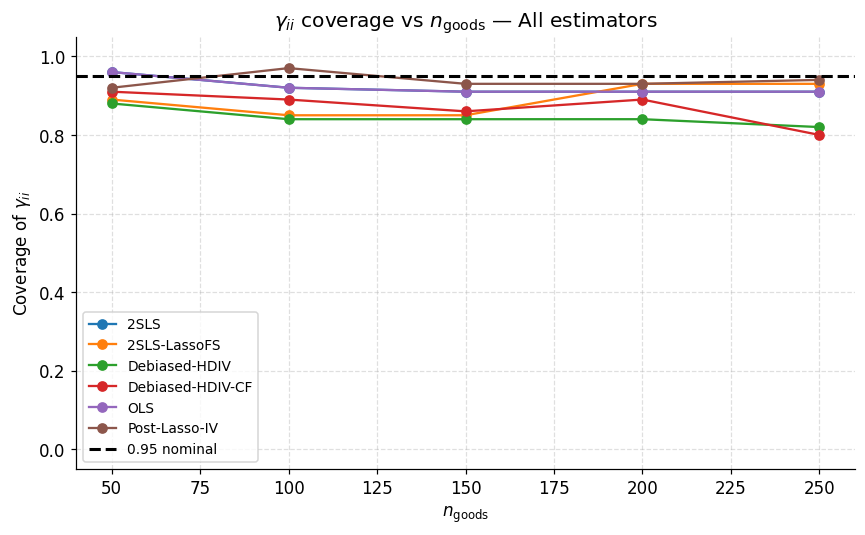

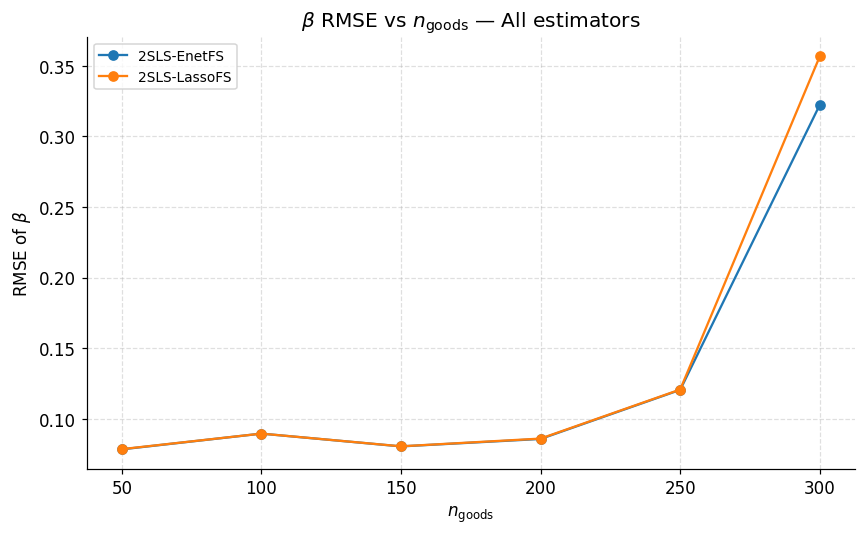

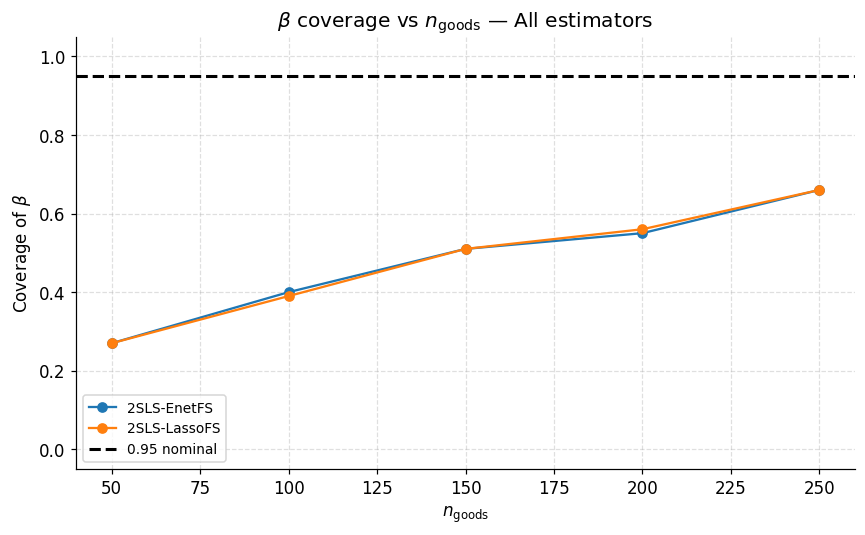

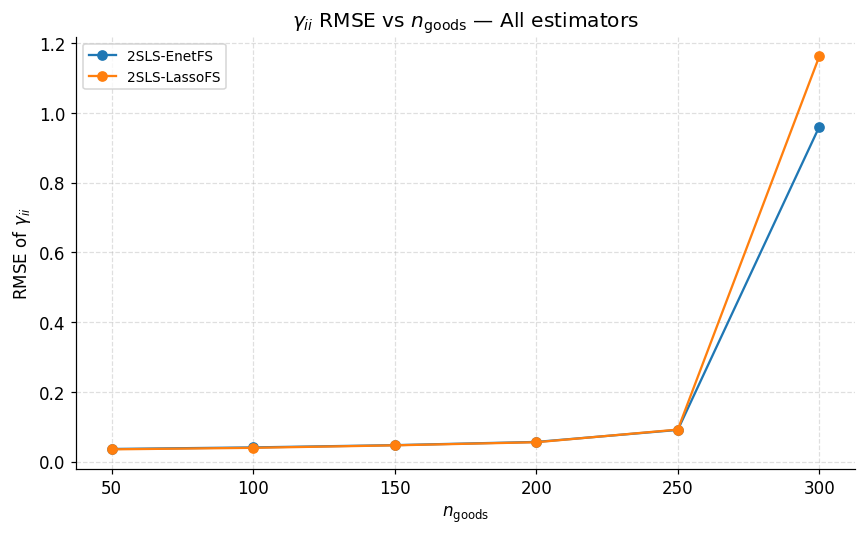

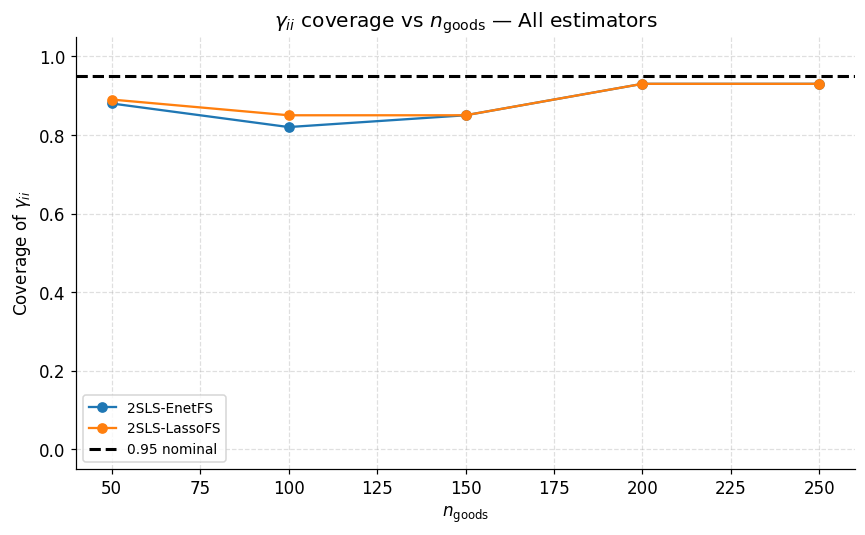

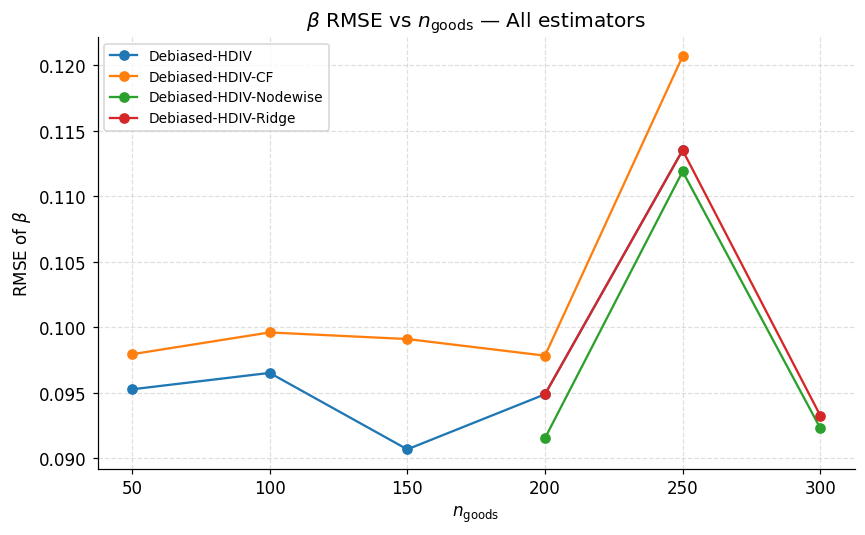

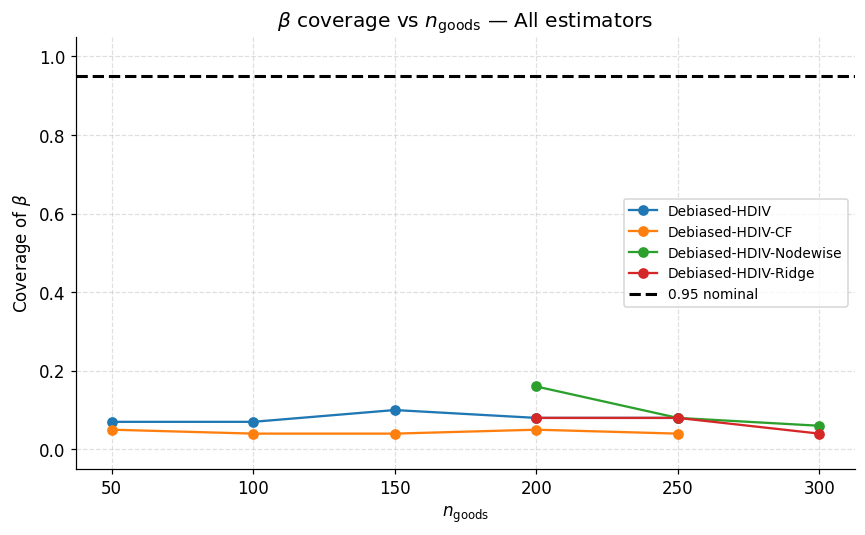

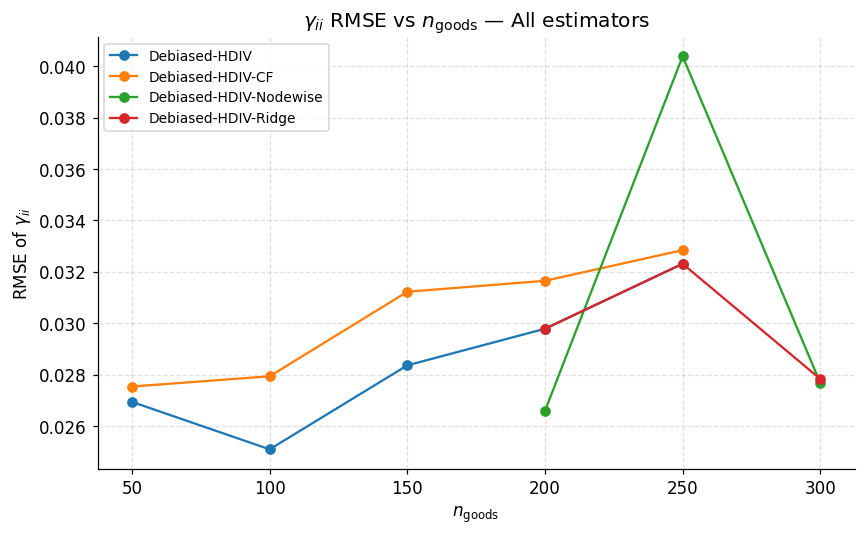

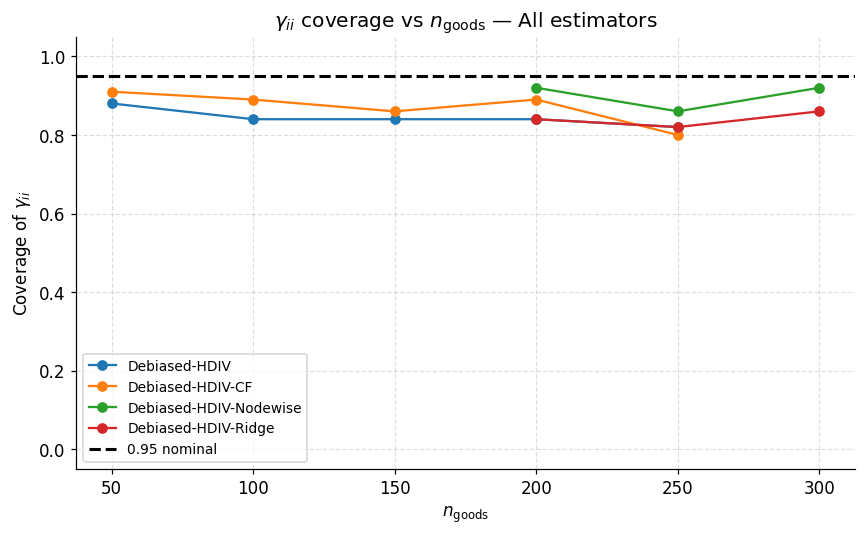

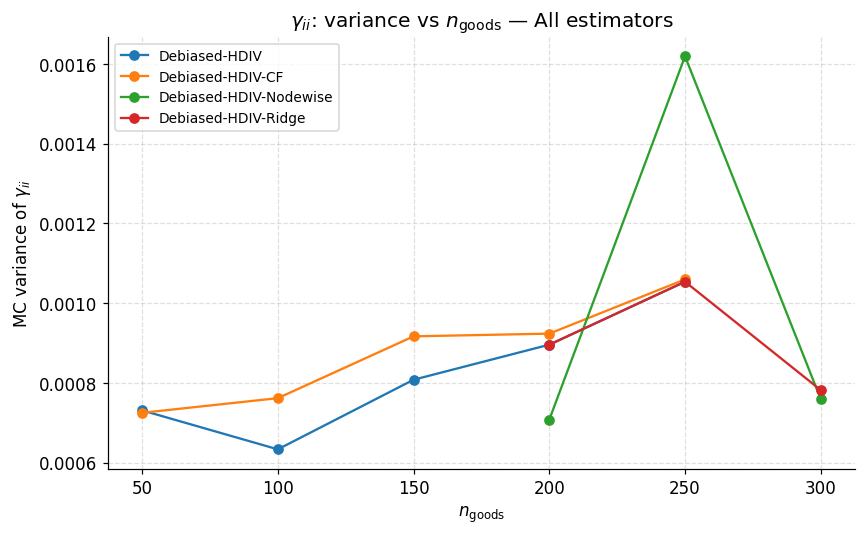

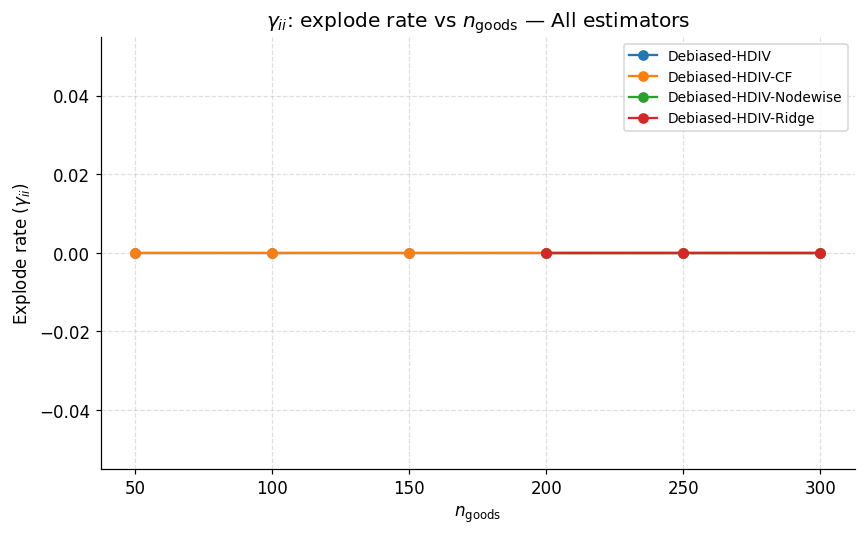

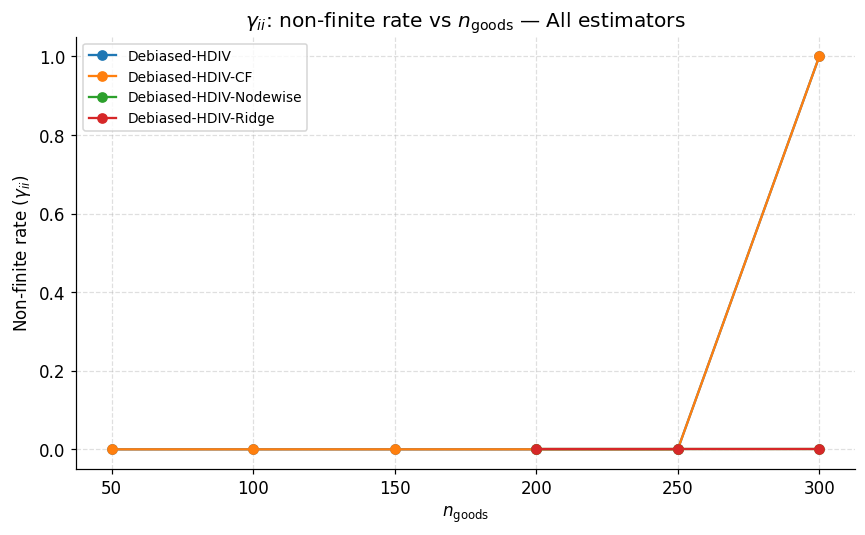

In [15]:
scen = "B_strongIV"
df = df_mc_n_main[scen]
aids_plots.set_filename_prefix("main_scenB_n")
for tgt in ("beta", "gii"):
    plot_mc_bands(df, xcol="n_goods", target=tgt, only_all=True)
    plot_rmse(df, xcol="n_goods", target=tgt, only_all=True)
    plot_coverage(df, xcol="n_goods", target=tgt, only_all=True)

# Estimator-level robustness: first-stage choice (Lasso vs. elastic net).
APPENDIX_FS_ROBUST = ["2SLS-LassoFS", "2SLS-EnetFS"]
df_fs = df_mc_n[scen][df_mc_n[scen]["estimator"].isin(APPENDIX_FS_ROBUST)].reset_index(drop=True)
aids_plots.set_filename_prefix("app_scenB_n_FSrobust")
for tgt in ("beta", "gii"):
    plot_rmse(df_fs, xcol="n_goods", target=tgt, only_all=True)
    plot_coverage(df_fs, xcol="n_goods", target=tgt, only_all=True)

# Estimator-level robustness: precision-matrix choice (CLIME, ridge, nodewise).
APPENDIX_PREC_ROBUST = ["Debiased-HDIV", "Debiased-HDIV-CF",
                       "Debiased-HDIV-Ridge", "Debiased-HDIV-Nodewise"]
df_prec = df_mc_n[scen][df_mc_n[scen]["estimator"].isin(APPENDIX_PREC_ROBUST)].reset_index(drop=True)
aids_plots.set_filename_prefix("app_scenB_n_PRECrobust")
for tgt in ("beta", "gii"):
    plot_rmse(df_prec, xcol="n_goods", target=tgt, only_all=True)
    plot_coverage(df_prec, xcol="n_goods", target=tgt, only_all=True)
plot_instability(df_prec, xcol="n_goods", target="gii", only_all=True)

#### Scenario B: instrument-count sweep

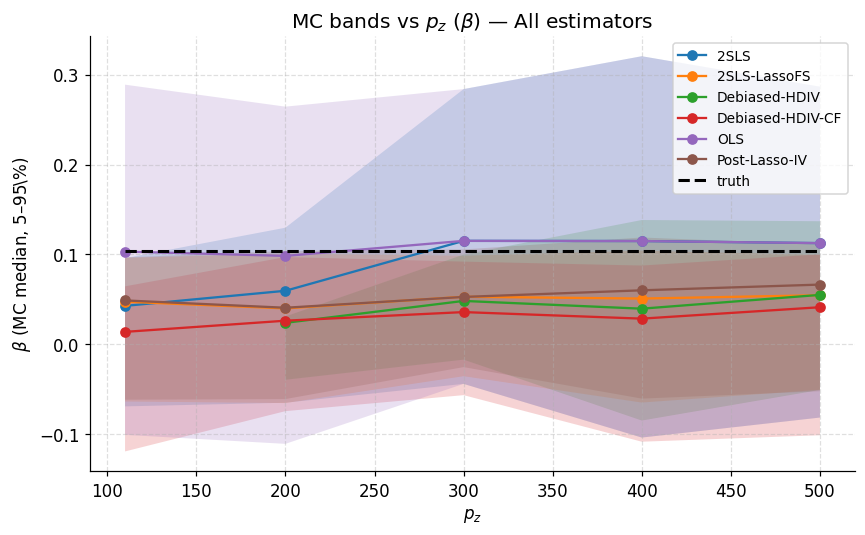

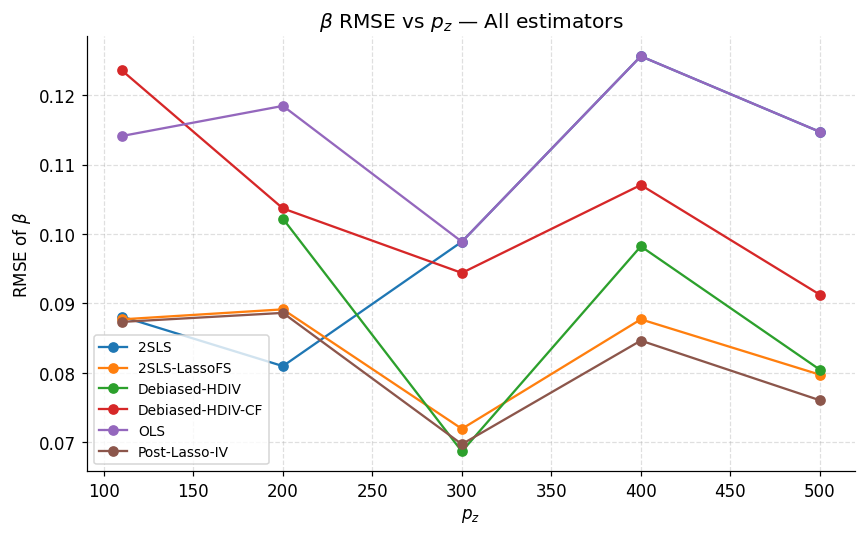

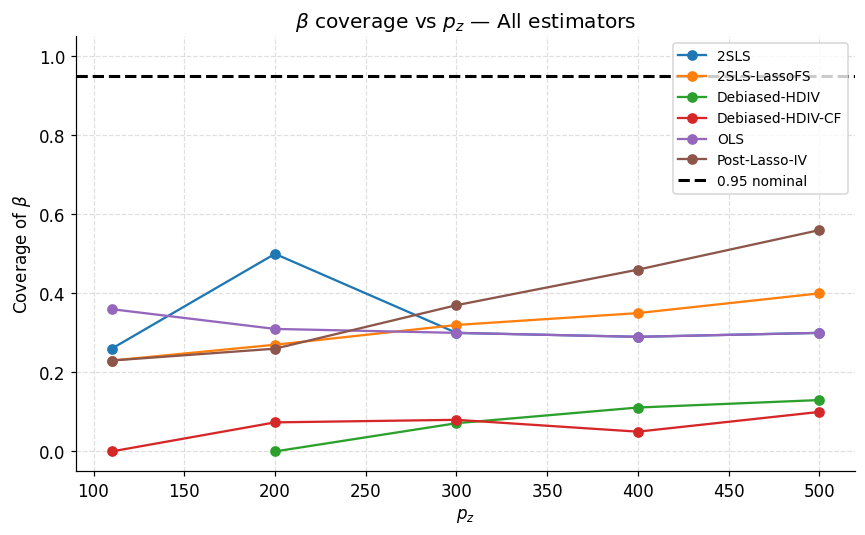

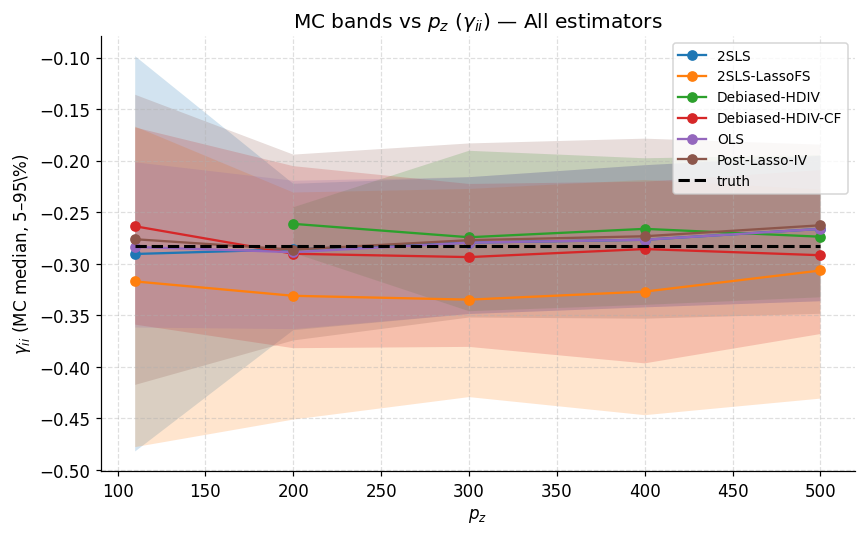

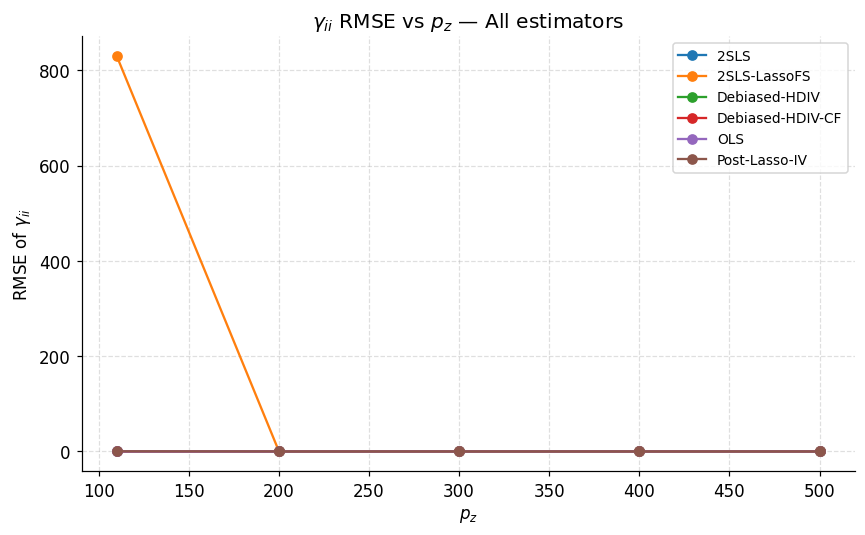

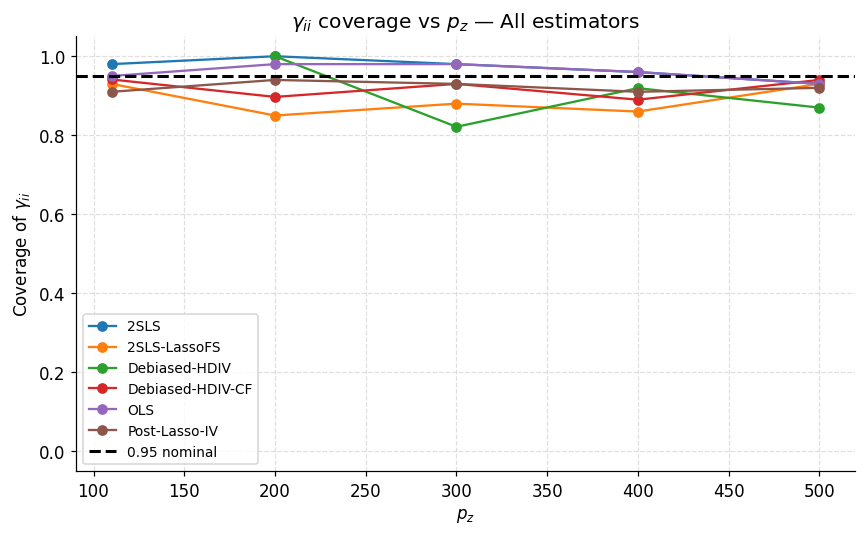

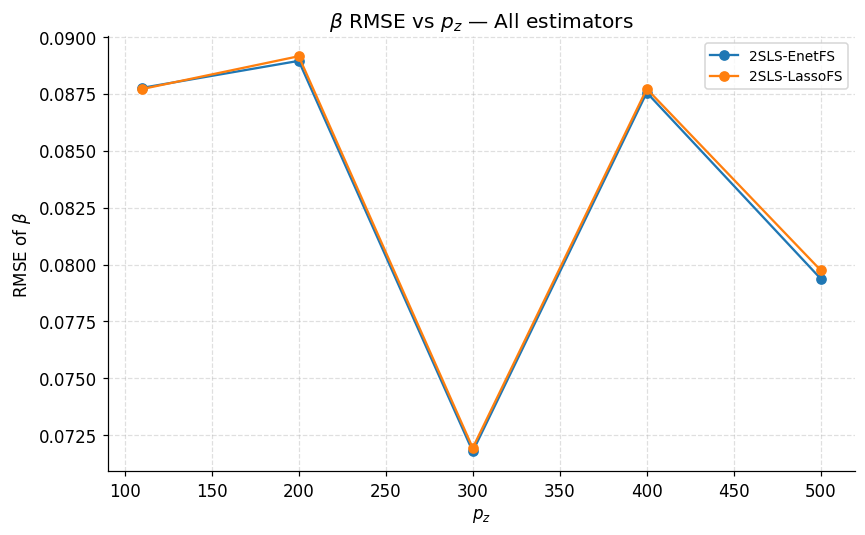

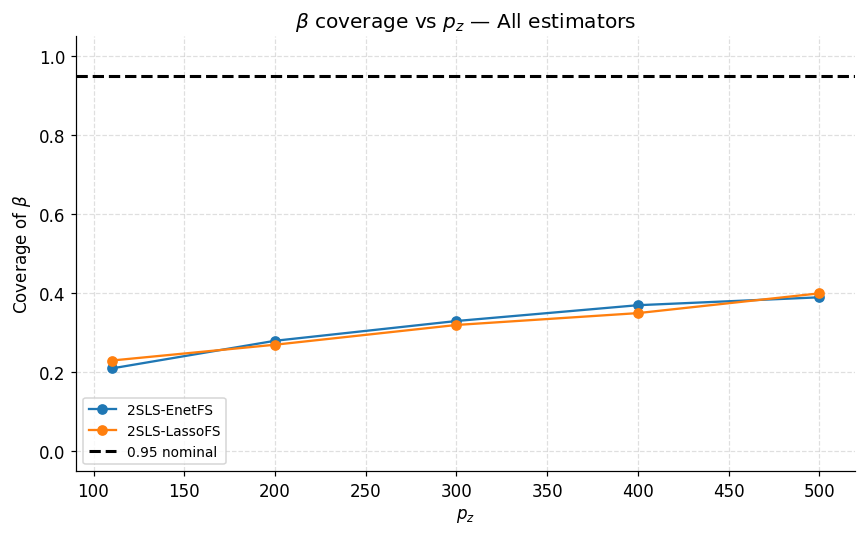

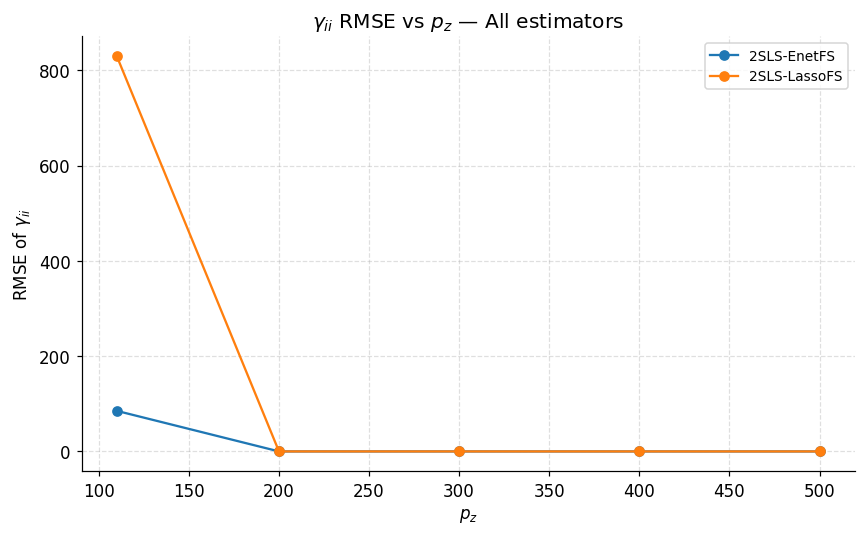

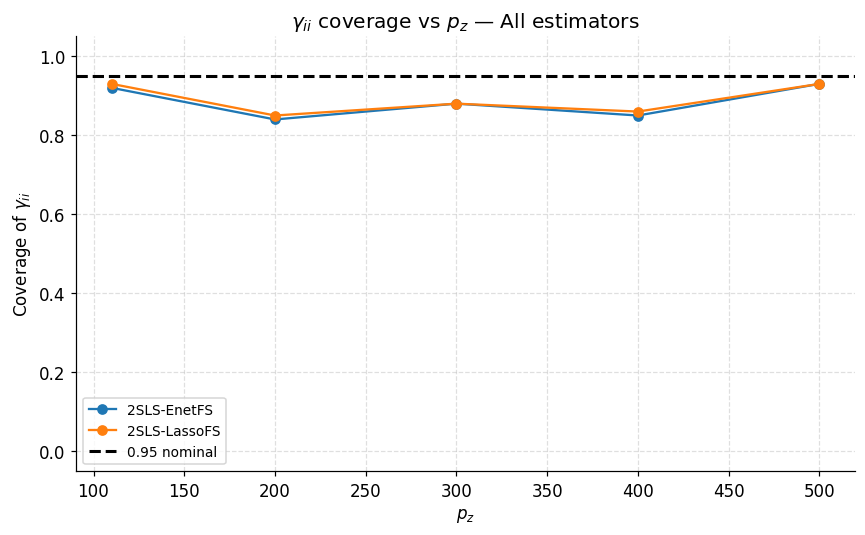

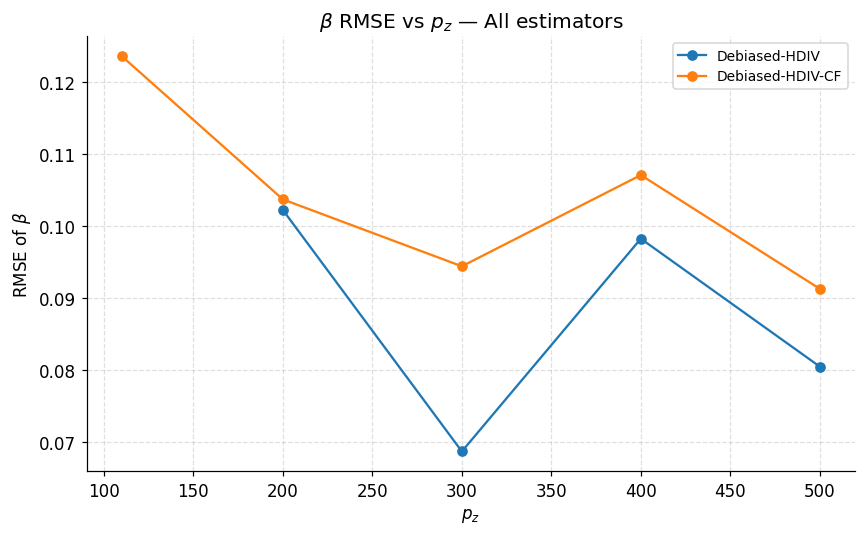

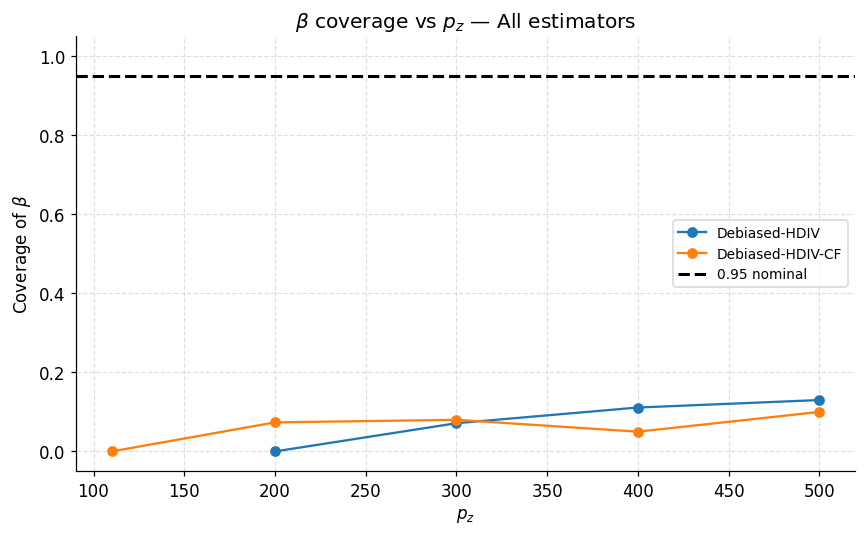

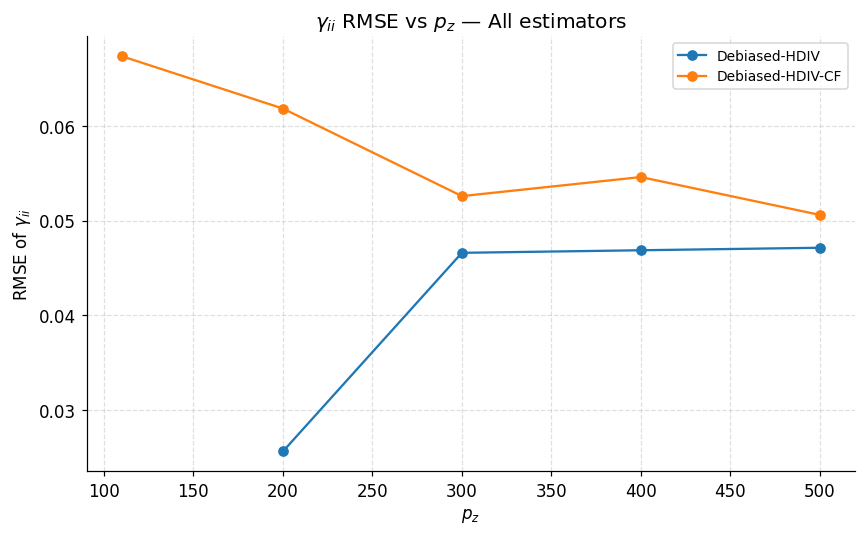

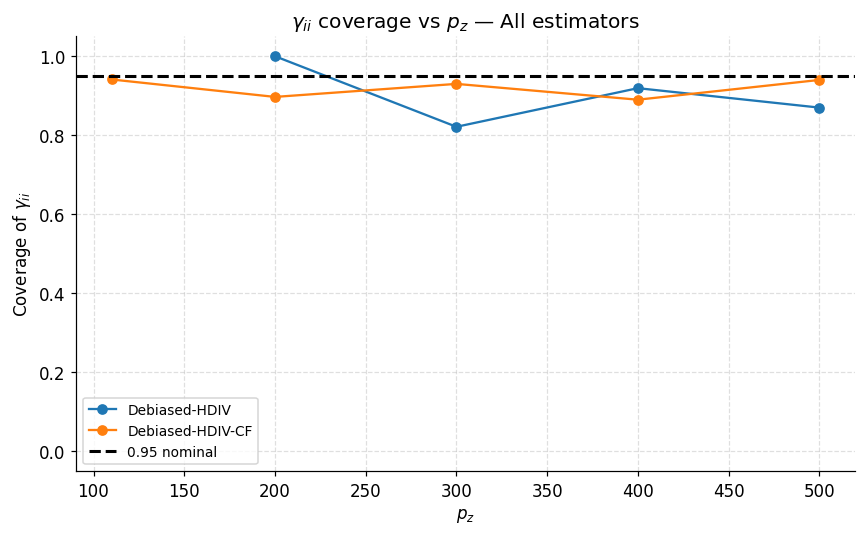

In [16]:
scen = "B_strongIV"
df = df_mc_pz_main[scen]
aids_plots.set_filename_prefix("main_scenB_pz")
for tgt in ("beta", "gii"):
    plot_mc_bands(df, xcol="pz", target=tgt, only_all=True)
    plot_rmse(df, xcol="pz", target=tgt, only_all=True)
    plot_coverage(df, xcol="pz", target=tgt, only_all=True)

# Estimator-level robustness: first-stage choice.
df_fs = df_mc_pz[scen][df_mc_pz[scen]["estimator"].isin(APPENDIX_FS_ROBUST)].reset_index(drop=True)
aids_plots.set_filename_prefix("app_scenB_pz_FSrobust")
for tgt in ("beta", "gii"):
    plot_rmse(df_fs, xcol="pz", target=tgt, only_all=True)
    plot_coverage(df_fs, xcol="pz", target=tgt, only_all=True)

# Estimator-level robustness: precision-matrix choice.
df_prec = df_mc_pz[scen][df_mc_pz[scen]["estimator"].isin(APPENDIX_PREC_ROBUST)].reset_index(drop=True)
aids_plots.set_filename_prefix("app_scenB_pz_PRECrobust")
for tgt in ("beta", "gii"):
    plot_rmse(df_prec, xcol="pz", target=tgt, only_all=True)
    plot_coverage(df_prec, xcol="pz", target=tgt, only_all=True)

### 5.3 Scenario C: weak instruments (paper §5.5.2, Appendix B.4)

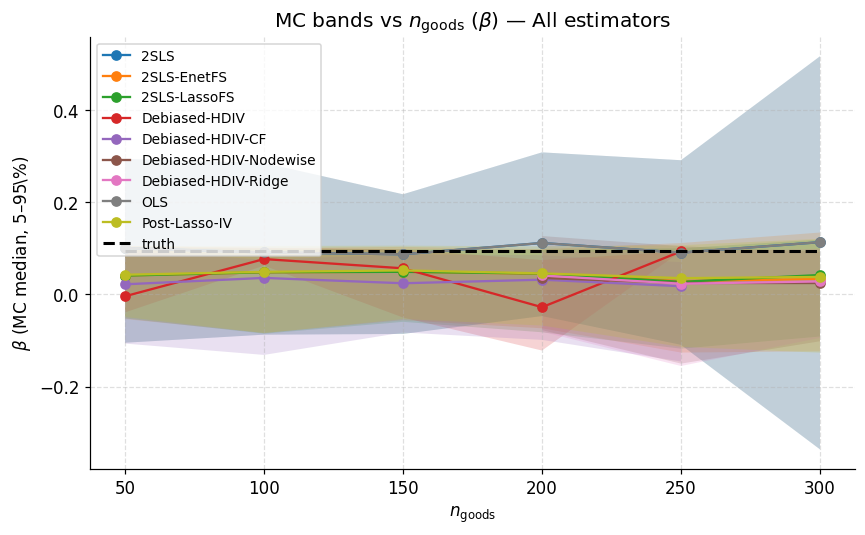

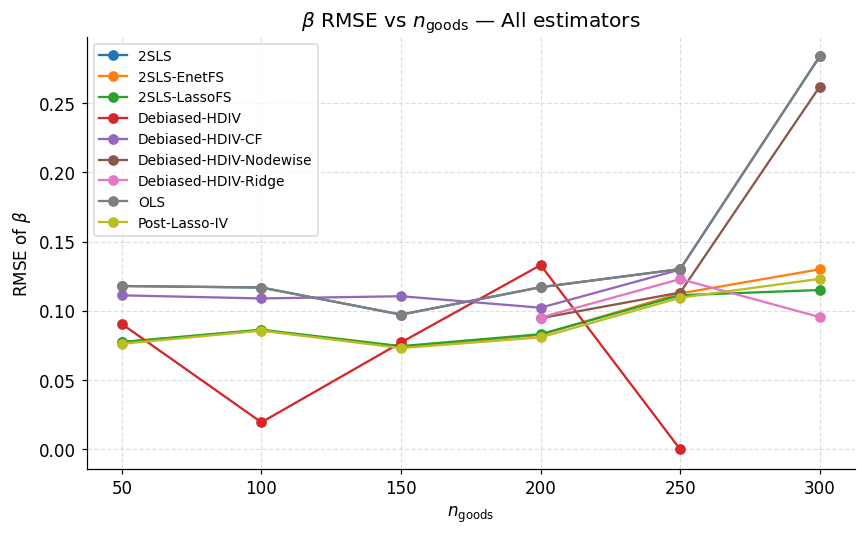

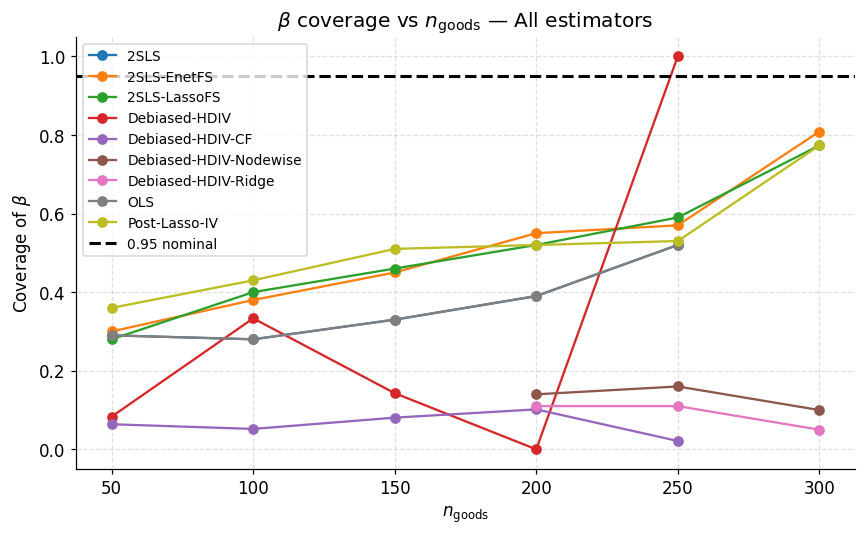

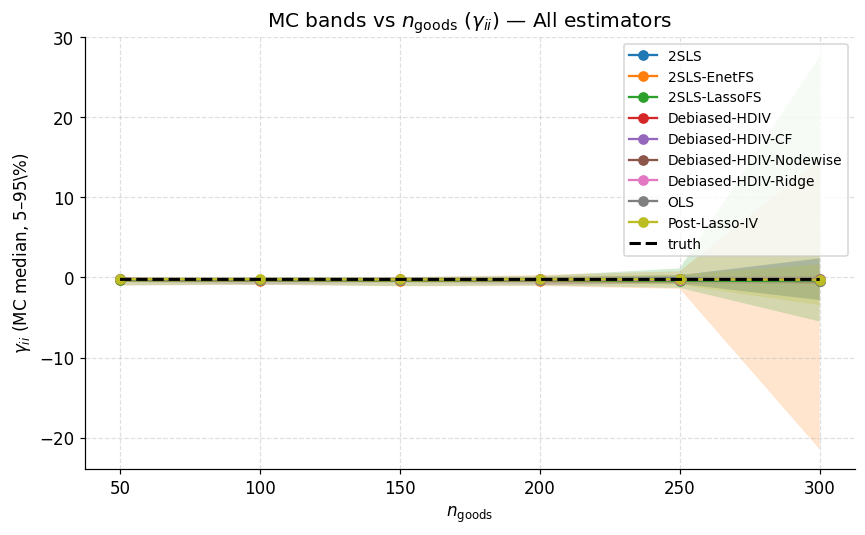

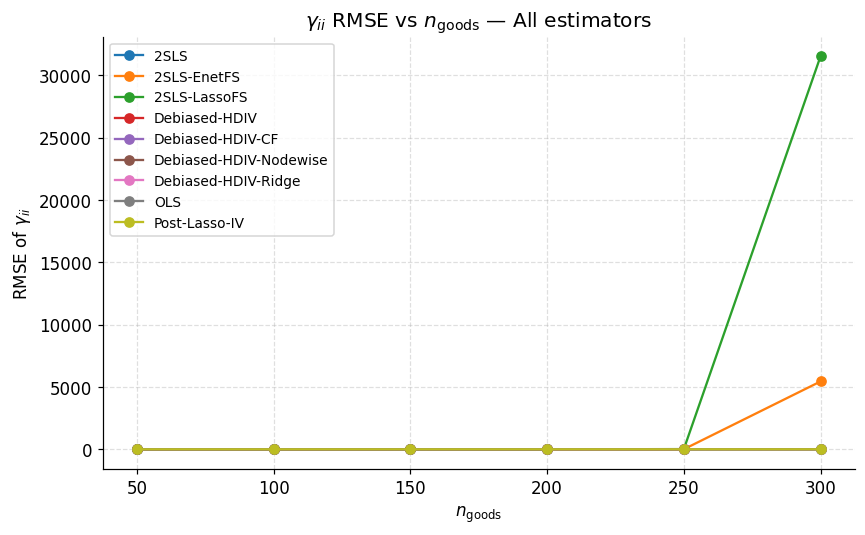

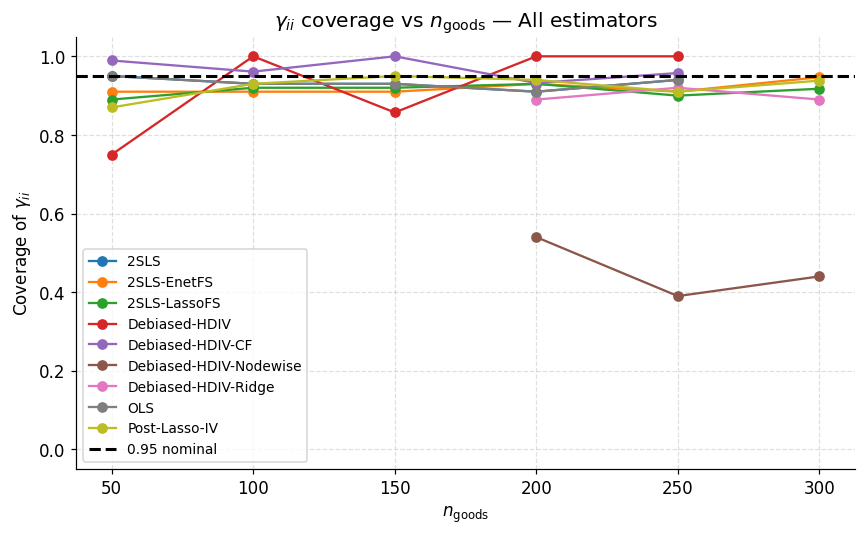

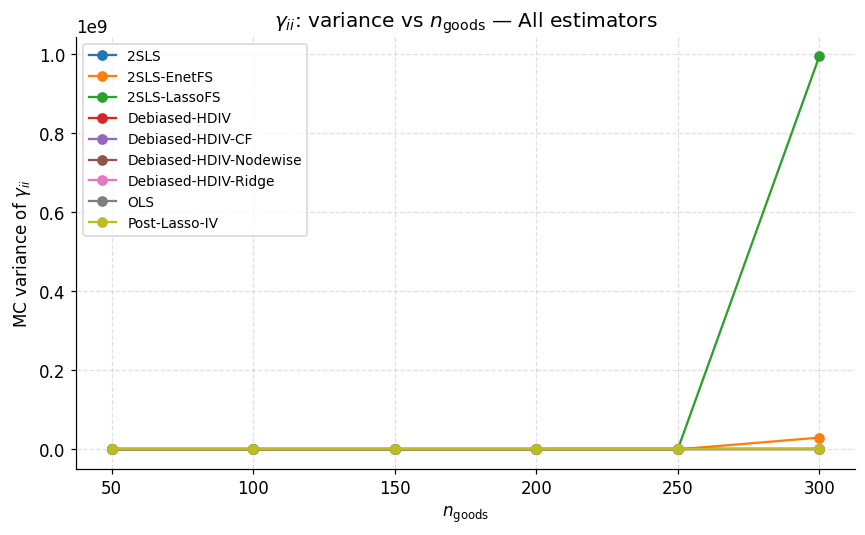

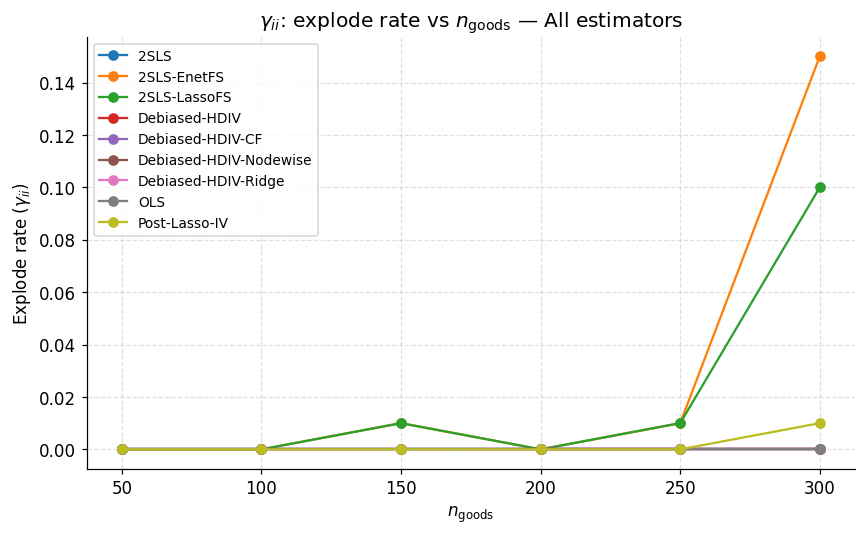

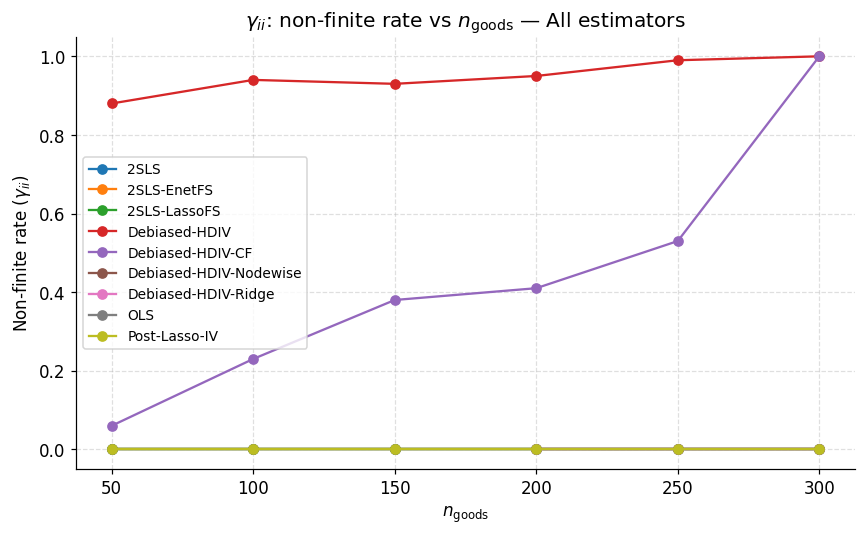

In [17]:
scen = "C_weakIV"
df = df_mc_n[scen]
aids_plots.set_filename_prefix("app_scenC_n")
for tgt in ("beta", "gii"):
    plot_mc_bands(df, xcol="n_goods", target=tgt, only_all=True)
    plot_rmse(df, xcol="n_goods", target=tgt, only_all=True)
    plot_coverage(df, xcol="n_goods", target=tgt, only_all=True)
plot_instability(df, xcol="n_goods", target="gii", only_all=True)

#### Scenario C: instrument-count sweep

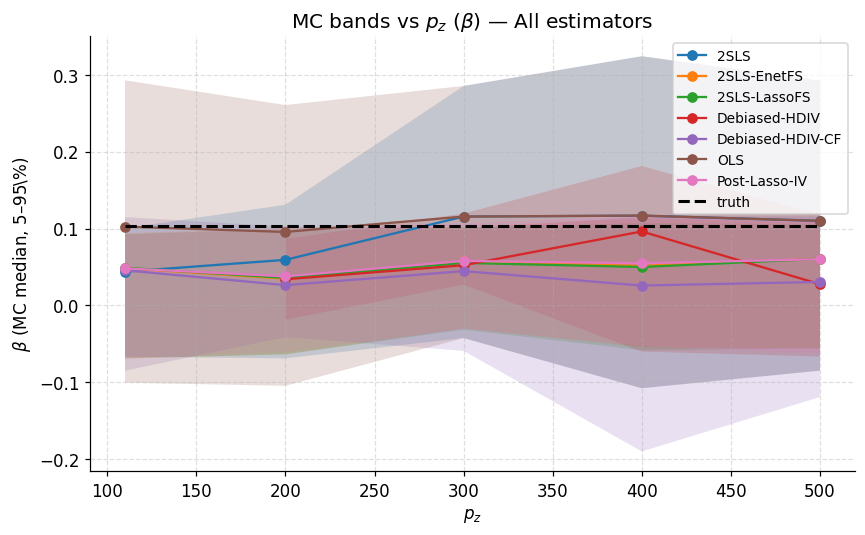

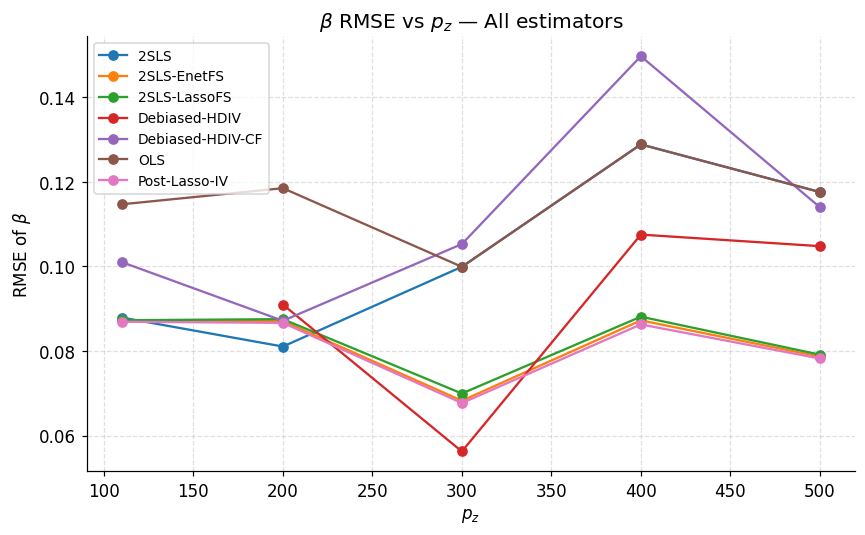

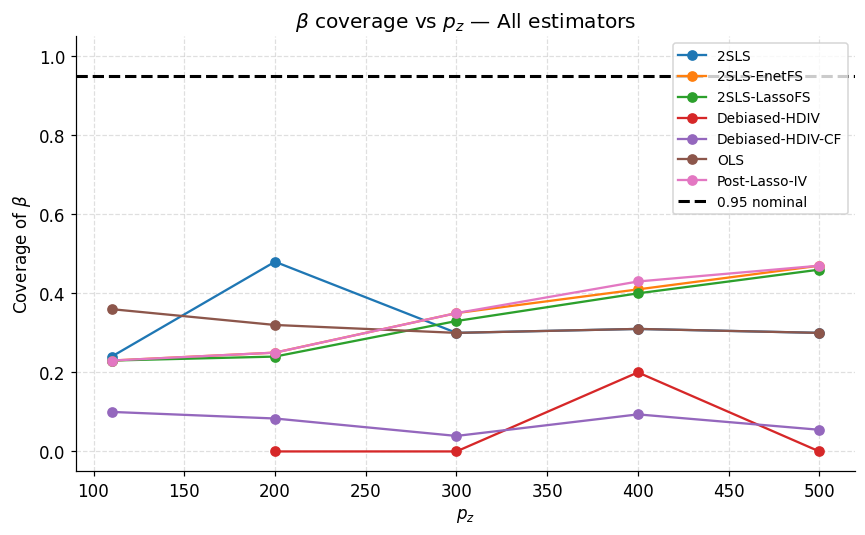

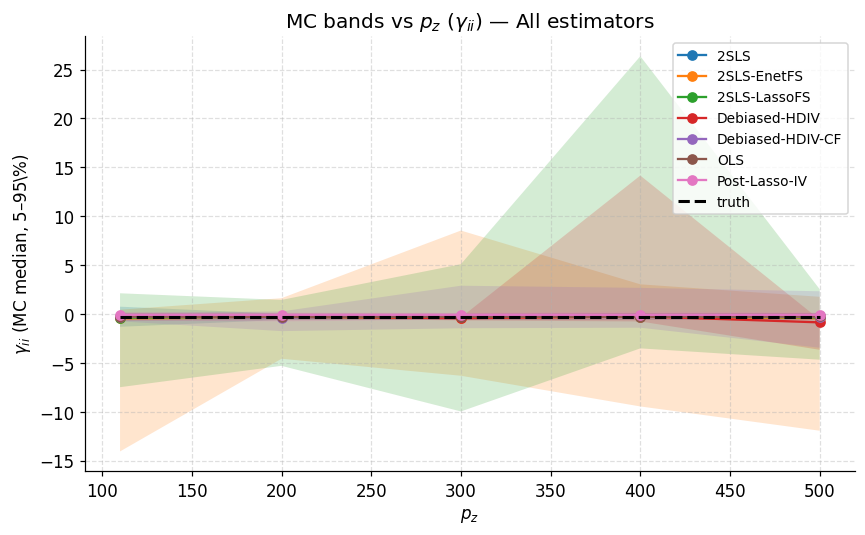

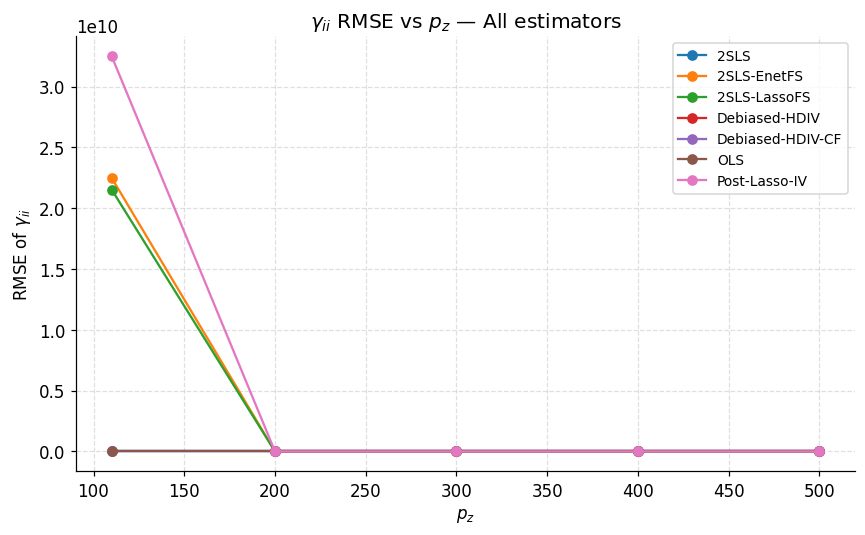

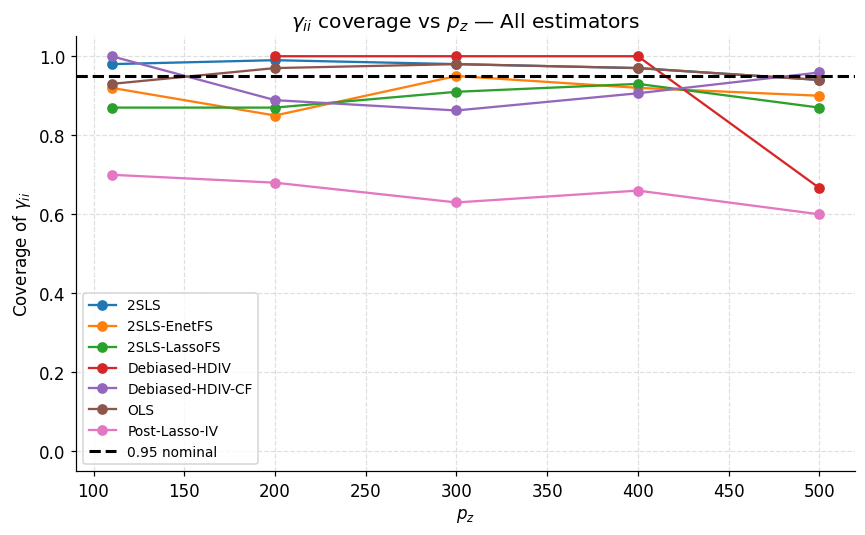

In [18]:
scen = "C_weakIV"
df = df_mc_pz[scen]
aids_plots.set_filename_prefix("app_scenC_pz")
for tgt in ("beta", "gii"):
    plot_mc_bands(df, xcol="pz", target=tgt, only_all=True)
    plot_rmse(df, xcol="pz", target=tgt, only_all=True)
    plot_coverage(df, xcol="pz", target=tgt, only_all=True)

## 6. Robustness (paper §5.6, Appendix B)

### 6.1 Sensitivity to the CLIME tuning parameter κ (paper Appendix B.2, Figure 17)

In [19]:
t0 = time.time()
scen = "B_strongIV"
params_fixed = draw_aids_params(
    max_n_goods=N_GOODS_DEFAULT, s_comp=5, param_seed=PARAM_SEED,
    max_pz=PZ_DEFAULT, k_instr_per_price=5,
)
rng = np.random.default_rng(SEED)
summ = simulate_aids_iv(
    T=T_DEFAULT, n_goods=N_GOODS_DEFAULT, pz=PZ_DEFAULT, i=0,
    rng=rng, params_fixed=params_fixed, param_seed=PARAM_SEED,
    **SCENARIOS[scen],
)
y, X, Z, meta = build_yX_from_summary(summ, i=0)
beta_true, gii_true = get_true_params(summ, i=0)

kappas = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
rows = []
for k in kappas:
    d = fit_debiased_hd_iv(
        y, X, Z, meta["endog_cols_prices"],
        idx_beta=meta["idx_beta"], idx_gamma_ii=meta["idx_gamma_ii"],
        crossfit=True, first_stage_kind="lasso", se_kind="sandwich",
        cv=5, random_state=SEED, kappa=k, lasso_n_jobs=1,
    )
    rows.append({
        "kappa": k, "mu": d["mu"],
        "beta_hat": d["b_tilde"][meta["idx_beta"]],
        "beta_se":  d["se_tilde"][meta["idx_beta"]],
        "gii_hat":  d["b_tilde"][meta["idx_gamma_ii"]],
        "gii_se":   d["se_tilde"][meta["idx_gamma_ii"]],
    })
print(f"elapsed: {time.time()-t0:.1f}s")
df_mu = pd.DataFrame(rows)
df_mu["beta_err"] = df_mu["beta_hat"] - beta_true
df_mu["gii_err"]  = df_mu["gii_hat"] - gii_true
df_mu.round(4)


elapsed: 964.4s


,kappa,mu,beta_hat,beta_se,gii_hat,gii_se,beta_err,gii_err
0,0.5,0.0621,-0.0108,0.0185,-0.2903,0.0712,-0.1145,-0.0077
1,0.8,0.0993,0.0093,0.0145,-0.3135,0.0654,-0.0944,-0.0310
2,1.0,0.1242,0.0229,0.0130,-0.3156,0.0638,-0.0808,-0.0331
3,1.2,0.1490,0.0289,0.0125,-0.3171,0.0612,-0.0748,-0.0345
4,1.5,0.1862,0.0299,0.0119,-0.3185,0.0582,-0.0738,-0.0359
5,2.0,0.2483,0.0316,0.0110,-0.3142,0.0537,-0.0721,-0.0316
6,3.0,0.3725,0.0350,0.0092,-0.3148,0.0454,-0.0687,-0.0322


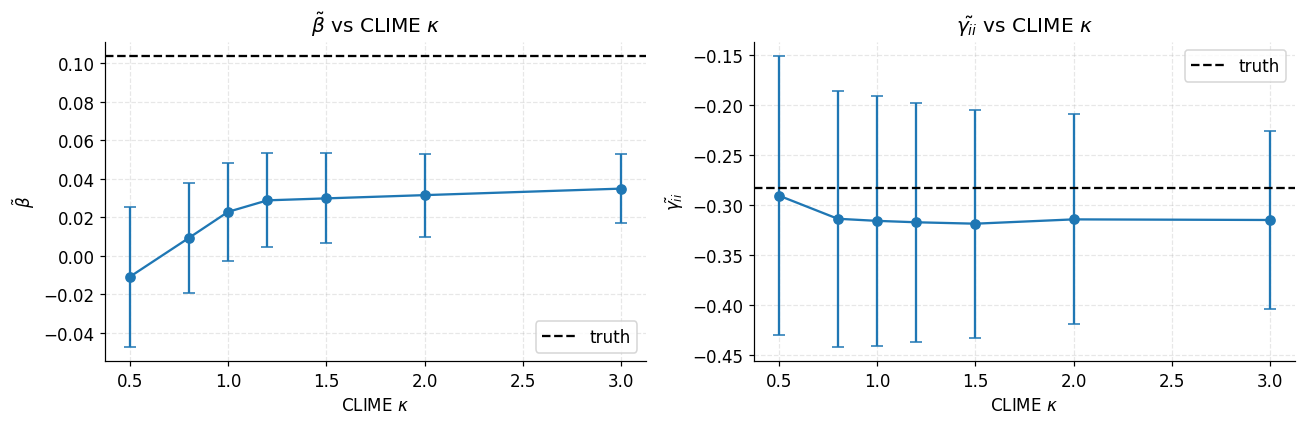

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, truth, label in [(axes[0], "beta_hat", beta_true, r"$\tilde{\beta}$"),
                              (axes[1], "gii_hat", gii_true, r"$\tilde{\gamma_{ii}}$")]:
    ax.errorbar(df_mu["kappa"], df_mu[col],
                yerr=1.96 * df_mu[col.replace("hat", "se")],
                fmt="o-", capsize=4)
    ax.axhline(truth, linestyle="--", color="k", label="truth")
    ax.set_xlabel(r"CLIME $\kappa$")
    ax.set_ylabel(label)
    ax.set_title(rf"{label} vs CLIME $\kappa$")
    ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Boundary regime (paper Appendix B.1, Figure 16)

In [21]:
DEBIASED_VARIANTS = ["Debiased-HDIV", "Debiased-HDIV-CF",
                     "Debiased-HDIV-Ridge", "Debiased-HDIV-Nodewise"]

df_appA = (
    df_mc_n["B_strongIV"]
    .query("n_goods == 300 & estimator in @DEBIASED_VARIANTS")
    .set_index("estimator")
    [["beta_bias", "beta_rmse", "beta_coverage", "beta_nan_rate",
      "gii_bias",  "gii_rmse",  "gii_coverage", "gii_nan_rate"]]
    .reindex(DEBIASED_VARIANTS)
    .round(3)
)

print("Boundary regime: debiased variants at n_goods=300 (p_x=302 > T=300)")
print("Scenario B (strong IV, endogenous prices)")
print()
print(df_appA.to_string())


Appendix A, Table 1: debiased variants at n_goods=300 (p=302 > T=300)
Scenario B (strong IV, endogenous prices)

                        beta_bias  beta_rmse  beta_coverage  beta_nan_rate  gii_bias  gii_rmse  gii_coverage  gii_nan_rate
estimator                                                                                                                 
Debiased-HDIV                 NaN        NaN            NaN            1.0       NaN       NaN           NaN           1.0
Debiased-HDIV-CF              NaN        NaN            NaN            1.0       NaN       NaN           NaN           1.0
Debiased-HDIV-Ridge        -0.074      0.093           0.04            0.0    -0.001     0.028          0.86           0.0
Debiased-HDIV-Nodewise     -0.073      0.092           0.06            0.0    -0.004     0.028          0.92           0.0


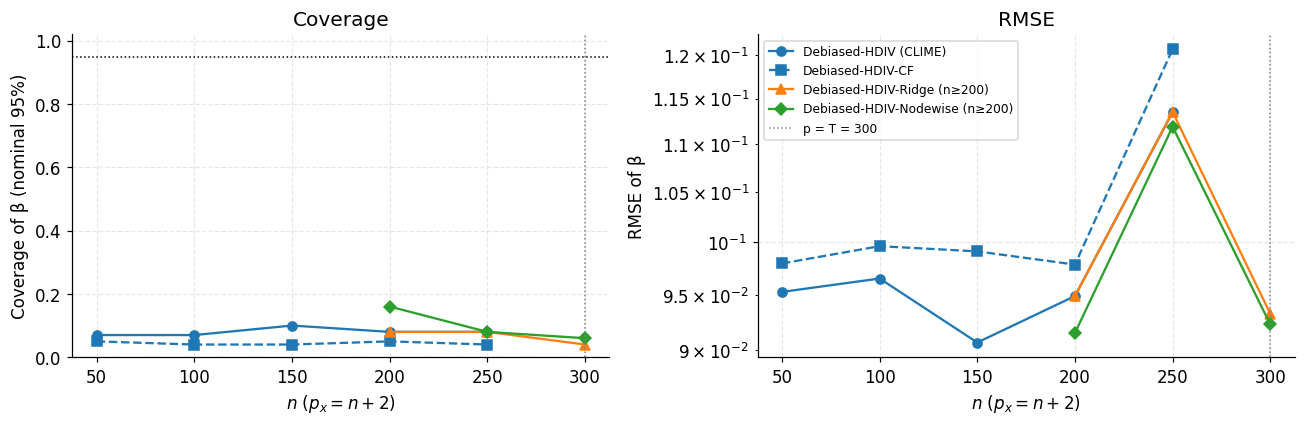

In [22]:
# Boundary regime: beta coverage and RMSE for the four debiased variants.
# Mainline CLIME variants return NaN at n_goods = 300 (p_x = 302 > T = 300);
# the ridge and nodewise variants are gated to n_goods >= 200.

DEBIASED_VARIANTS = ["Debiased-HDIV", "Debiased-HDIV-CF",
                     "Debiased-HDIV-Ridge", "Debiased-HDIV-Nodewise"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sub = df_mc_n["B_strongIV"].query("estimator in @DEBIASED_VARIANTS")

style = {
    "Debiased-HDIV":          {"marker": "o", "ls": "-",  "color": "C0",
                               "label": "Debiased-HDIV (CLIME)"},
    "Debiased-HDIV-CF":       {"marker": "s", "ls": "--", "color": "C0",
                               "label": "Debiased-HDIV-CF"},
    "Debiased-HDIV-Ridge":    {"marker": "^", "ls": "-",  "color": "C1",
                               "label": "Debiased-HDIV-Ridge (n≥200)"},
    "Debiased-HDIV-Nodewise": {"marker": "D", "ls": "-",  "color": "C2",
                               "label": "Debiased-HDIV-Nodewise (n≥200)"},
}

for est, st in style.items():
    g = sub[sub.estimator == est].sort_values("n_goods")
    g_cov  = g.dropna(subset=["beta_coverage"])
    g_rmse = g.dropna(subset=["beta_rmse"])
    if not g_cov.empty:
        axes[0].plot(g_cov.n_goods,  g_cov.beta_coverage, **st)
    if not g_rmse.empty:
        axes[1].plot(g_rmse.n_goods, g_rmse.beta_rmse,    **st)

for ax in axes:
    ax.axvline(T_DEFAULT, color="grey", ls=":", lw=1, label=f"p = T = {T_DEFAULT}")
    ax.set_xlabel("$n$ ($p_x = n + 2$)")
    ax.grid(alpha=0.3)

axes[0].axhline(0.95, color="black", ls=":", lw=1)
axes[0].set_ylabel("Coverage of β (nominal 95%)")
axes[0].set_ylim(0, 1.02)
axes[0].set_title("Coverage")

axes[1].set_ylabel("RMSE of β")
axes[1].set_yscale("log")
axes[1].set_title("RMSE")
axes[1].legend(fontsize=8, loc="best")

plt.tight_layout()
if Path("paper_results").exists():
    plt.savefig("paper_results/figA_debiased_variants_B.pdf", bbox_inches="tight")
plt.show()


## 7. Replication archive

Writes every cached Monte Carlo result to `paper_results/` as CSV.

In [23]:
CSV_DIR = Path("paper_results")
CSV_DIR.mkdir(exist_ok=True)

for scen in SCENARIOS:
    if scen in df_mc_n:
        df_mc_n[scen].to_csv(CSV_DIR / f"mc_n_{scen}.csv", index=False)
for scen in ["B_strongIV", "C_weakIV"]:
    if scen in df_mc_pz:
        df_mc_pz[scen].to_csv(CSV_DIR / f"mc_pz_{scen}.csv", index=False)
print(f"Exported to {CSV_DIR.resolve()}:")
for p in sorted(CSV_DIR.glob("*.csv")):
    print(f"  {p.name}  ({p.stat().st_size//1024} KB)")


if "df_appA" in dir():
    df_appA.to_csv(CSV_DIR / "appA_n300_variant_comparison.csv")


Exported to /Users/shababahmed/Library/CloudStorage/Dropbox/Research/Empirical/AIDS/New_Code/paper_results:
  mc_n_A_no_endo.csv  (17 KB)
  mc_n_B_strongIV.csv  (17 KB)
  mc_n_C_weakIV.csv  (17 KB)
  mc_pz_B_strongIV.csv  (12 KB)
  mc_pz_C_weakIV.csv  (12 KB)
